# Análise do perfil acadêmico/demográfico + histórico escolar dos discentes do curso de computação
**Objetivo:** Realizar análises descritivas, exploratórias e inferenciais, além de aplicar testes estatísticos para validar hipóteses sobre evasão e desempenho dos estudantes do curso de Ciência da Computação.

### Súmario
1. [Carga e preparação dos dados](#dados)
    - 1.1. [Análise Exploratória](#eda)
2. [Perfil dos alunos](#perfil)
    - 2.1. [Distribuição por sexo, raça, faixa etária, estado civil, nacionalidade.](#distribuiçao)
    - 2.2. [Proporção de evasão vs conclusão por perfil demográfico.](#proporçao)
    - 2.3. [Análise de correlação entre coeficiente de rendimento e evasão.](#analise)
3. [Trajetória acadêmica](#trajetoria)
    - 3.1. [Taxa média de aprovação/reprovação por disciplina.](#taxa)
    - 3.2. [Identificação de disciplinas gargalo (com maior índice de reprovação).](#identificao)
    - 3.3. [Evolução do desempenho do aluno por período (notas e faltas).](#evolucao)
    - 3.4. [Relação entre reprovações acumuladas e evasão.](#relacao)
4. [Comparação entre grupos](#comp)
    - 4.1. [Diferenças no coeficiente de rendimento por sexo, raça, tipo de ingresso.](#difeCoeficiente)
    - 4.2. [Diferença entre evasão por forma de ingresso (ENEM, transferência, e tipos de Cotas).](#difeEvasao)
5. [Testes estatísticos recomendados](#teste)
    - 5.1. [Comparações de médias](#media)
    - 5.2. [Associação entre variáveis catégoricas](#associacao)
    - 5.3. [Correlação](#corr)
    - 5.4. [Comparação de distribuições](#comp)
    - 5.5. [Modelagem estatística](#model)
6. [Conclusão Final](#conclusao)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import ks_2samp
import statsmodels.api as sm
from statsmodels.formula.api import ols
from datetime import date


<a id='dados'></a>
## 1. Carga e preparação dos dados
Nesta seção, carregamos os três datasets necessários (`alunos_ativos`, `alunos_inativos`, `historico_escolar`)

### Vamos utilizar os datasets
- **alunos_ativos.csv:** Contém informações sobre os alunos que estão atualmente ativos na instituição.
- **alunos_inativos.csv:** Conjunto de dados contém informações sobre os alunos que não estão mais ativos na instituição.
- **historico_escolar.csv:** Conjunto de dados detalha o histórico acadêmico dos alunos, com informações sobre as disciplinas cursadas.

In [ ]:
alunosAtivos = pd.read_csv('alunos_ativos.csv')
alunosInativos = pd.read_csv('alunos_inativos.csv') 
histEscolar = pd.read_csv('historico_escolar.csv')

<a id='eda'></a>
### 1.1 Análise Exploratória (EDA)
Realizamos uma análise exploratória para entender a distribuição dos dados, verificar valores nulos, duplicados e tratar inconsistências.

In [ ]:
display(alunosAtivos.head())
display(alunosInativos.head())
display(histEscolar.head())

,Data Nascimento,Sexo,Raça,Estrangeiro,Nacionalidade,Naturalidade,UF Naturalidade,Período,Situação atual,Data ocorrência,Estrutura,Período ingresso,Tipo ingresso,IMI,Coeficiente,Tipo de demanda,rga_anonimo
0,2000-01-14,Masculino,"Pardo(a),Mulato(a)",Não,BRASILEIRO,ARAGARCAS,GO,20232,MATRICULADO NO PERÍODO,2023-11-16,20191,20181,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),56.7,5.49,L6 - Estudante preto pardo ou indígena de esco...,af05b362ddb9224c4589b23cbf119b60ce7e26300b6a3a...
1,1997-04-26,Masculino,"Pardo(a),Mulato(a)",Não,BRASILEIRO,SAO JOSE DO JACUIPE,BA,20232,AFASTAMENTO POR BLOQUEIO DE MATRICULA,2023-11-10,20191,20171,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),35.8,4.42,Ampla Concorrência,208844f5f871e3b92a344f0a6f7782b209872e5667ea13...
2,1999-09-04,Masculino,Negra,Não,BRASILEIRO,BARRA DO GARCAS,MT,20232,MATRICULADO NO PERÍODO,2023-12-01,20191,20171,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),50.1,5.93,Ampla Concorrência,157770a9bd112bd511d5fed47b295121e2be2e9d082f84...
3,1994-06-05,Masculino,"Pardo(a),Mulato(a)",Não,BRASILEIRO,SAO JOSÉ DO XINGU,MT,20232,AFASTAMENTO POR BLOQUEIO DE MATRICULA,2023-11-10,20191,20131,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),59.7,7.03,L4 - Estudante preto pardo ou indígena de esco...,71260f57df37913cf04b8a5f882737c071c9313b201158...
4,2004-05-24,Feminino,Branca,Não,BRASILEIRO,GOIANIA,GO,20232,AFASTAMENTO POR TRANCAMENTO DE MATRICULA,2023-11-30,20191,20221,INGRESSO POR PROCESSO SELETIVO ESPECÍFICO,50.8,4.78,Ampla Concorrência,d517234d3868dee3fc27d4ff1dee463e9d68b45d51ad22...


,Data Nascimento,Sexo,Raça,Estrangeiro,Nacionalidade,Naturalidade,UF Naturalidade,Período,Situação atual,Data ocorrência,Estrutura,Período ingresso,Tipo ingresso,IMI,Coeficiente,Tipo de demanda,rga_anonimo
0,1993-05-08,Masculino,Branca,Não,BRASILEIRO,ARAGARCAS,GO,20161,EXCLUSÃO POR DESLIGAMENTO - RESOLUÇÃO CONSEPE ...,2016-06-27,20091,20111,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),3.8,1.63,NaN,c31ebda923a730829336347280e50dcf10d35aa6f7de02...
1,1988-02-06,Feminino,"Pardo(a),Mulato(a)",Não,BRASILEIRO,PARAGOMINAS,PA,20221,EXCLUSAO POR CONCLUSAO (FORMADO),2023-02-10,20191,20141,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),68.6,6.95,L4 - Estudante preto pardo ou indígena de esco...,8a417431c97e7d34315177679327cc45414bbf093d4f07...
2,1991-11-26,Masculino,"Pardo(a),Mulato(a)",Não,BRASILEIRO,BARRA DO GARCAS - MT,MT,20131,EXCLUSAO POR CONCLUSAO (FORMADO),2013-09-19,20091,20091,INGRESSO POR TRANSFERENCIA DE REGIME,0.0,4.47,NaN,b251f5c111876bb185fdaf7f58535b4a6f3c8e924ab679...
3,1995-01-23,Masculino,Negra,Não,BRASILEIRO,BARRA DO GARCAS,MT,20192,EXCLUSÃO POR DESLIGAMENTO - RESOLUÇÃO CONSEPE ...,2019-11-12,20191,20161,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),0.0,0.00,L4 - Estudante preto pardo ou indígena de esco...,bf92b6a19e2b440d38ce69047587601b82314875b4d0f3...
4,1986-12-25,Masculino,Branca,Não,BRASILEIRO,MARABA,PA,20222,EXCLUSAO POR DESISTENCIA,2023-04-24,20191,20221,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),0.0,0.00,Ampla Concorrência,8beccafee2f40a099063c8631c8ecb1b760240d502e0e4...


,Ano,Código,Nome da Disciplina,CH,CR,TU,MF,FA,SF,SE,rga_anonimo,Disciplina,Grupo de Disciplinas,Tipo de Disciplina,Optativa
0,2010/1,72100022,FUNDAMENTOS DE MATEMÁTICA,64,4,CC,3.3,6,RM,1,e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...,Fundamentos de Matemática,Fundamentos de Matemática,Matemática,Não
1,2010/1,72100023,GEOMETRIA ANALÍTICA E VETORIAL,96,6,CC,5.0,0,AP,1,e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...,Geometria Analítica e Vetorial,Geometria,Matemática,Não
2,2010/1,70400377,Lógica Matemática e Elementos de Lógica Digital,96,6,CC,5.0,0,AP,1,e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...,Lógica Digital,Lógica Digital,Computação,Não
3,2010/1,70400375,Programação I,96,6,CC,4.6,4,RM,1,e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...,Programação I,Programação,Computação,Não
4,2010/1,72000016,Práticas de Leitura e Produção de Textos,96,6,CC,7.1,4,AP,1,e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...,Práticas de Leitura e Produção de Texto,Práticas de Leitura e Produção de Texto,Linguagens,Não


In [ ]:
print(f"Linhas e colunas do dataset alunosAtivos: {alunosAtivos.shape}")
print(f"Linhas e colunas do dataset alunosInativos: {alunosInativos.shape}")
print(f"Linhas e colunas do dataset histEscolar: {histEscolar.shape}")

Linhas e colunas do dataset alunosAtivos: (220, 17)
Linhas e colunas do dataset alunosInativos: (498, 17)
Linhas e colunas do dataset histEscolar: (19528, 15)


In [ ]:
print(f"Informações do dataset alunosAtivos:\n{alunosAtivos.info()}\n")
print(f"Informações do dataset alunosInativos:\n{alunosInativos.info()}\n")
print(f"Informações do dataset histEscolar:\n{histEscolar.info()}\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Data Nascimento   220 non-null    object 
 1   Sexo              220 non-null    object 
 2   Raça              220 non-null    object 
 3   Estrangeiro       220 non-null    object 
 4   Nacionalidade     220 non-null    object 
 5   Naturalidade      220 non-null    object 
 6   UF Naturalidade   220 non-null    object 
 7   Período           220 non-null    int64  
 8   Situação atual    220 non-null    object 
 9   Data ocorrência   220 non-null    object 
 10  Estrutura         220 non-null    int64  
 11  Período ingresso  220 non-null    int64  
 12  Tipo ingresso     220 non-null    object 
 13  IMI               220 non-null    float64
 14  Coeficiente       220 non-null    float64
 15  Tipo de demanda   219 non-null    object 
 16  rga_anonimo       220 non-null    object 
dt

In [ ]:
#Consultando valores nulos
print(f"Valores nulos no dataset alunosAtivos:\n{alunosAtivos.isnull().sum()}\n")
print(f"Valores nulos no dataset alunosInativos:\n{alunosInativos.isnull().sum()}\n")
print(f"Valores nulos no dataset historicoEscolar:\n{histEscolar.isnull().sum()}\n")

Valores nulos no dataset alunosAtivos:
Data Nascimento     0
Sexo                0
Raça                0
Estrangeiro         0
Nacionalidade       0
Naturalidade        0
UF Naturalidade     0
Período             0
Situação atual      0
Data ocorrência     0
Estrutura           0
Período ingresso    0
Tipo ingresso       0
IMI                 0
Coeficiente         0
Tipo de demanda     1
rga_anonimo         0
dtype: int64

Valores nulos no dataset alunosInativos:
Data Nascimento       0
Sexo                  0
Raça                  0
Estrangeiro           0
Nacionalidade         0
Naturalidade         16
UF Naturalidade      38
Período               0
Situação atual        0
Data ocorrência      34
Estrutura             0
Período ingresso      0
Tipo ingresso         0
IMI                   0
Coeficiente           0
Tipo de demanda     191
rga_anonimo           0
dtype: int64

Valores nulos no dataset historicoEscolar:
Ano                     0
Código                  0
Nome da Discipl

In [ ]:
# Consultando valores duplicados
print(f"Valores duplicados no dataset alunosAtivos: {alunosAtivos.duplicated().sum()}")
print(f"Valores duplicados no dataset alunosInativos: {alunosInativos.duplicated().sum()}")
print(f"Valores duplicados no dataset historicoEscolar: {histEscolar.duplicated().sum()}")

Valores duplicados no dataset alunosAtivos: 0
Valores duplicados no dataset alunosInativos: 0
Valores duplicados no dataset historicoEscolar: 0


## 2. Perfil dos Alunos

### 2.1 - Distribuição por sexo, raça, faixa etária, estado civil, nacionalidade.

In [ ]:
# Padronização de nomes de colunas
alunosAtivos.columns = alunosAtivos.columns.str.lower().str.strip().str.replace(" ", "_")
alunosInativos.columns = alunosInativos.columns.str.lower().str.strip().str.replace(" ", "_")

In [ ]:
# Criar coluna "status" para identificar evasão
alunosAtivos["status"] = "ativo"
alunosInativos["status"] = "inativo"

In [ ]:
# Juntar os dois DataFrames
df_unificado = pd.concat([alunosAtivos, alunosInativos], ignore_index=True)

In [ ]:
# Conferir dados
print("Total de alunos:", df_unificado.shape[0])
print(df_unificado.head())
print(f'O DataFrame unificado tem {df_unificado.shape[0]} linhas e {df_unificado.shape[1]} colunas.')

Total de alunos: 718
  data_nascimento       sexo                raça estrangeiro nacionalidade  \
0      2000-01-14  Masculino  Pardo(a),Mulato(a)         Não    BRASILEIRO   
1      1997-04-26  Masculino  Pardo(a),Mulato(a)         Não    BRASILEIRO   
2      1999-09-04  Masculino               Negra         Não    BRASILEIRO   
3      1994-06-05  Masculino  Pardo(a),Mulato(a)         Não    BRASILEIRO   
4      2004-05-24   Feminino              Branca         Não    BRASILEIRO   

          naturalidade uf_naturalidade  período  \
0            ARAGARCAS              GO    20232   
1  SAO JOSE DO JACUIPE              BA    20232   
2      BARRA DO GARCAS              MT    20232   
3    SAO JOSÉ DO XINGU              MT    20232   
4              GOIANIA              GO    20232   

                             situação_atual data_ocorrência  estrutura  \
0                    MATRICULADO NO PERÍODO      2023-11-16      20191   
1     AFASTAMENTO POR BLOQUEIO DE MATRICULA      2023-1

In [ ]:
df_unificado.columns = df_unificado.columns.str.strip()
print(df_unificado.columns)

Index(['data_nascimento', 'sexo', 'raça', 'estrangeiro', 'nacionalidade',
       'naturalidade', 'uf_naturalidade', 'período', 'situação_atual',
       'data_ocorrência', 'estrutura', 'período_ingresso', 'tipo_ingresso',
       'imi', 'coeficiente', 'tipo_de_demanda', 'rga_anonimo', 'status'],
      dtype='object')


In [ ]:
df_unificado['Categoria'] = df_unificado['situação_atual'].apply(
    lambda x: 'Concluinte' if 'FORMADO' in str(x) else ('Evadido' if 'EXCLUSÃO' in str(x) else 'Ativo')
)

In [ ]:
# Converter a coluna 'Coeficiente' para tipo numérico e remover valores ausentes
df_unificado['coeficiente'] = pd.to_numeric(df_unificado['coeficiente'], errors='coerce')
df_analise = df_unificado.dropna(subset=['coeficiente']).copy()

In [ ]:
# Filtrar o DataFrame para incluir apenas os alunos Concluintes e Evadidos
df_finalizado = df_analise[df_analise['Categoria'].isin(['Concluinte', 'Evadido'])].copy()

In [ ]:
# Comparar o Coeficiente médio dos dois grupos
media_evadidos = df_finalizado[df_finalizado['Categoria'] == 'Evadido']['coeficiente'].mean()
media_concluintes = df_finalizado[df_finalizado['Categoria'] == 'Concluinte']['coeficiente'].mean()

print(f"Coeficiente médio dos alunos evadidos: {media_evadidos:.2f}")
print(f"Coeficiente médio dos alunos concluintes: {media_concluintes:.2f}")

Coeficiente médio dos alunos evadidos: 2.13
Coeficiente médio dos alunos concluintes: 6.40


/tmp/ipykernel_582/2322368243.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_finalizado, x='Categoria', y='coeficiente', palette='coolwarm')


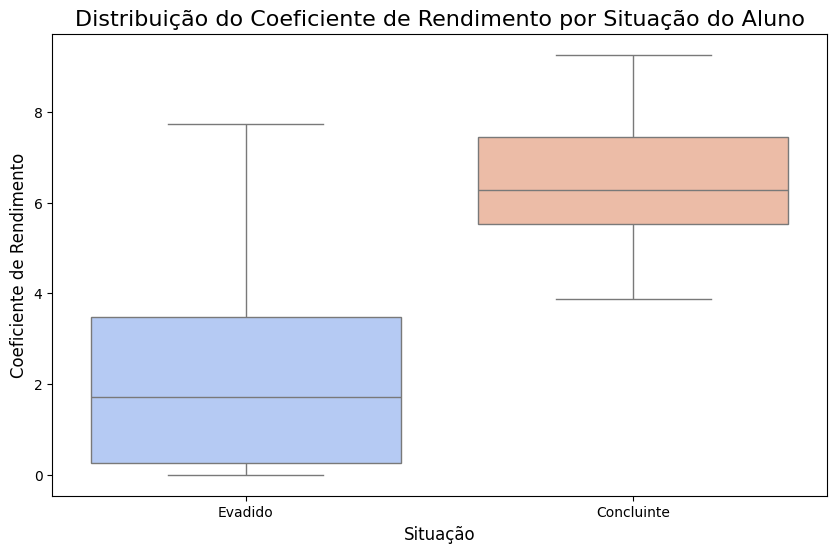

In [ ]:
# box plot para visualizar a distribuição do Coeficiente por categoria
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_finalizado, x='Categoria', y='coeficiente', palette='coolwarm')
plt.title('Distribuição do Coeficiente de Rendimento por Situação do Aluno', fontsize=16)
plt.xlabel('Situação', fontsize=12)
plt.ylabel('Coeficiente de Rendimento', fontsize=12)
plt.show()

/tmp/ipykernel_582/2569692444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_unificado, x='sexo', palette='pastel')


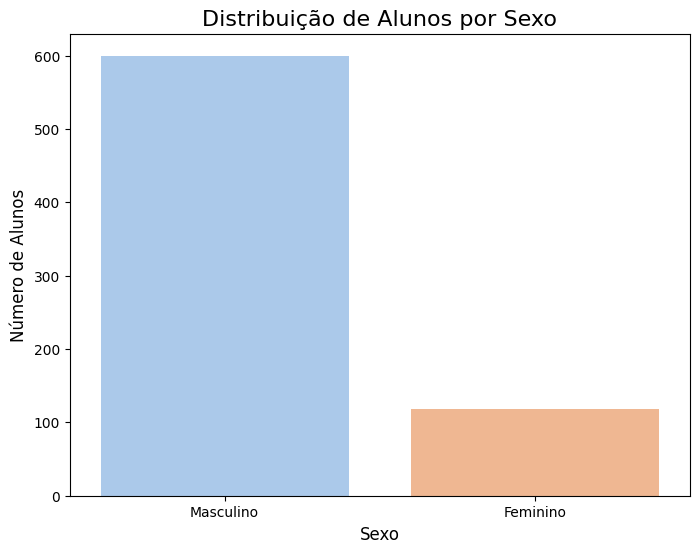

In [ ]:
# Gráfico de Distribuição por Sexo
plt.figure(figsize=(8, 6))
sns.countplot(data=df_unificado, x='sexo', palette='pastel')
plt.title('Distribuição de Alunos por Sexo', fontsize=16)
plt.xlabel('Sexo', fontsize=12)
plt.ylabel('Número de Alunos', fontsize=12)
plt.show()

/tmp/ipykernel_582/2058338597.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_unificado, y='raça', order=df_unificado['raça'].value_counts().index, palette='pastel')


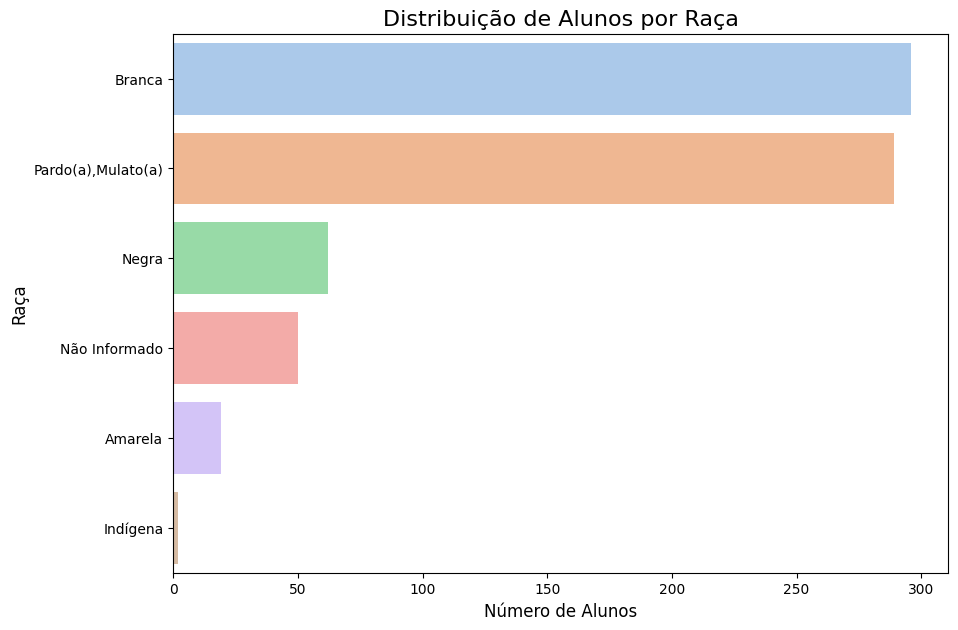

In [ ]:
# Gráfico de Distribuição por Raça
plt.figure(figsize=(10, 7))
sns.countplot(data=df_unificado, y='raça', order=df_unificado['raça'].value_counts().index, palette='pastel')
plt.title('Distribuição de Alunos por Raça', fontsize=16)
plt.xlabel('Número de Alunos', fontsize=12)
plt.ylabel('Raça', fontsize=12)
plt.show()

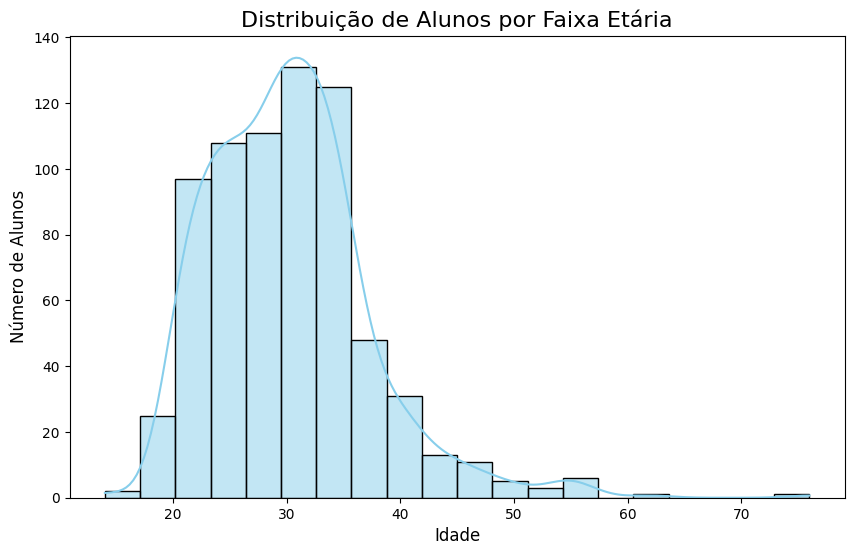

In [ ]:
# Gráfico de Distribuição por Faixa Etária
# Primeiro calcula a idade de cada aluno
df_unificado['data_nascimento'] = pd.to_datetime(df_unificado['data_nascimento'])
hoje = pd.to_datetime(date.today())
df_unificado['Idade'] = (hoje - df_unificado['data_nascimento']).dt.days // 365.25

plt.figure(figsize=(10, 6))
sns.histplot(data=df_unificado, x='Idade', bins=20, kde=True, color='skyblue')
plt.title('Distribuição de Alunos por Faixa Etária', fontsize=16)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Número de Alunos', fontsize=12)
plt.show()

/tmp/ipykernel_582/800166506.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_unificado, y='nacionalidade', order=df_unificado['nacionalidade'].value_counts().index, palette='pastel')


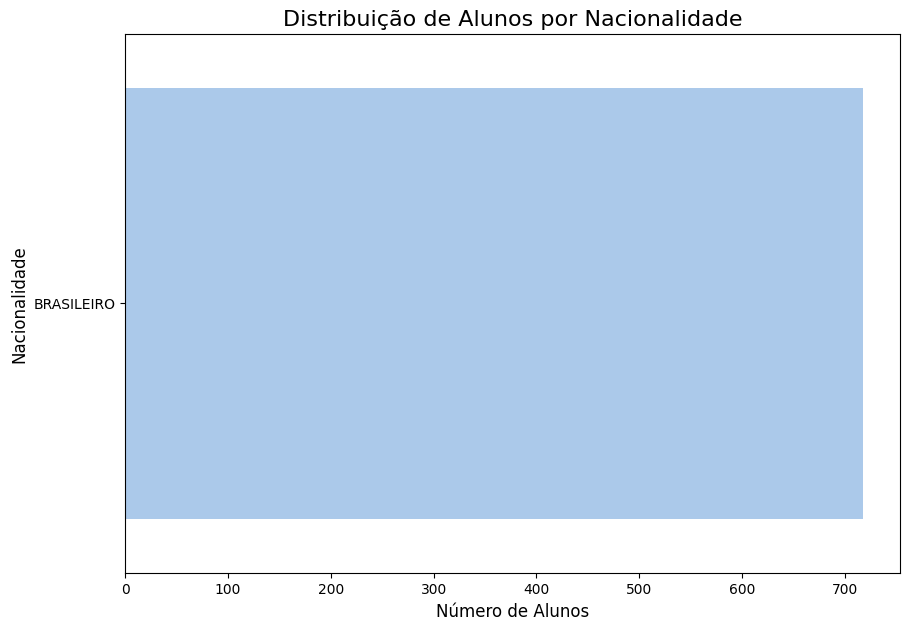

In [ ]:
plt.figure(figsize=(10, 7))
sns.countplot(data=df_unificado, y='nacionalidade', order=df_unificado['nacionalidade'].value_counts().index, palette='pastel')
plt.title('Distribuição de Alunos por Nacionalidade', fontsize=16)
plt.xlabel('Número de Alunos', fontsize=12)
plt.ylabel('Nacionalidade', fontsize=12)
plt.show()

### 2.2 - Proporção de evasão vs conclusão por perfil demográfico.

In [ ]:
# Criar a coluna 'Categoria' para análise de evasão
df_unificado['Categoria'] = df_unificado['situação_atual'].apply(
    lambda x: 'Concluinte' if 'FORMADO' in str(x) else ('Evadido' if 'EXCLUSÃO' in str(x) else 'Ativo')
)

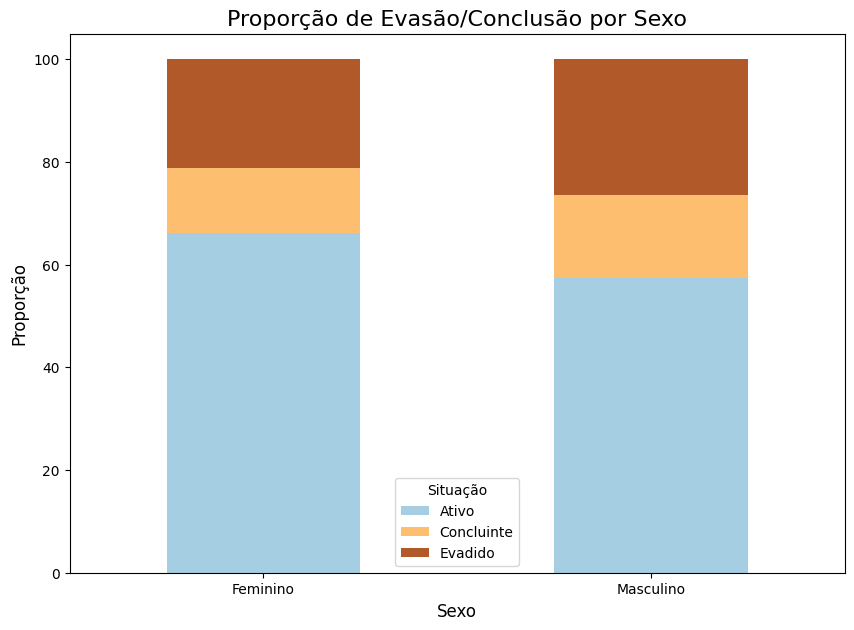

In [ ]:
# Gráfico da porcentagem de alunos em cada categoria (Evadido, Concluinte, Ativo) para ambos os sexos.

# Tabela de contagem
sexo_evasao = (df_unificado
               .groupby(['sexo', 'Categoria'])
               .size()
               .unstack(fill_value=0))

# Converter para proporção (%)
sexo_evasao = sexo_evasao.div(sexo_evasao.sum(axis=1), axis=0) * 100

sexo_evasao.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='Paired')
plt.title('Proporção de Evasão/Conclusão por Sexo', fontsize=16)
plt.xlabel('Sexo', fontsize=12)
plt.ylabel('Proporção', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Situação')
plt.show()


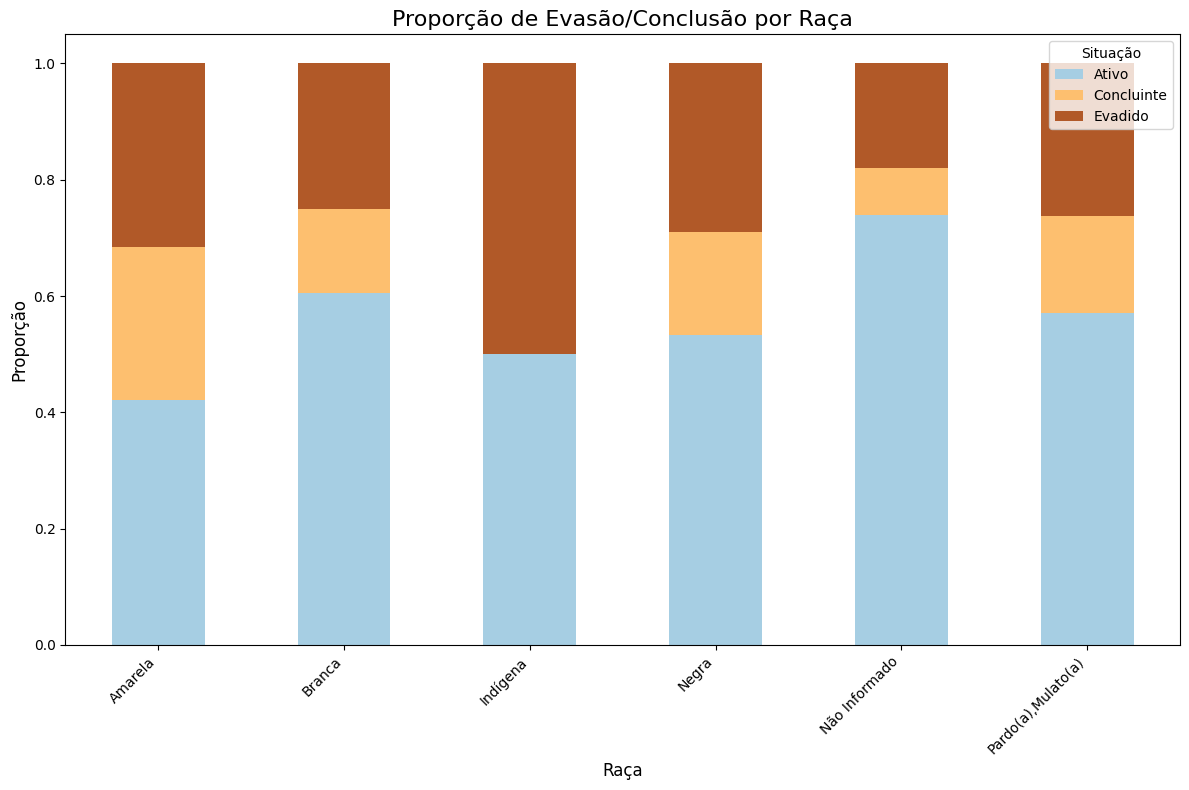

In [ ]:
# Gráfico da proporção de Evasaõ vs Conclusão por Raça
raca_evasao = df_unificado.groupby('raça')['Categoria'].value_counts(normalize=True).unstack().fillna(0)
raca_evasao = raca_evasao[['Ativo', 'Concluinte', 'Evadido']]

raca_evasao.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='Paired')
plt.title('Proporção de Evasão/Conclusão por Raça', fontsize=16)
plt.xlabel('Raça', fontsize=12)
plt.ylabel('Proporção', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Situação')
plt.tight_layout()
plt.show()

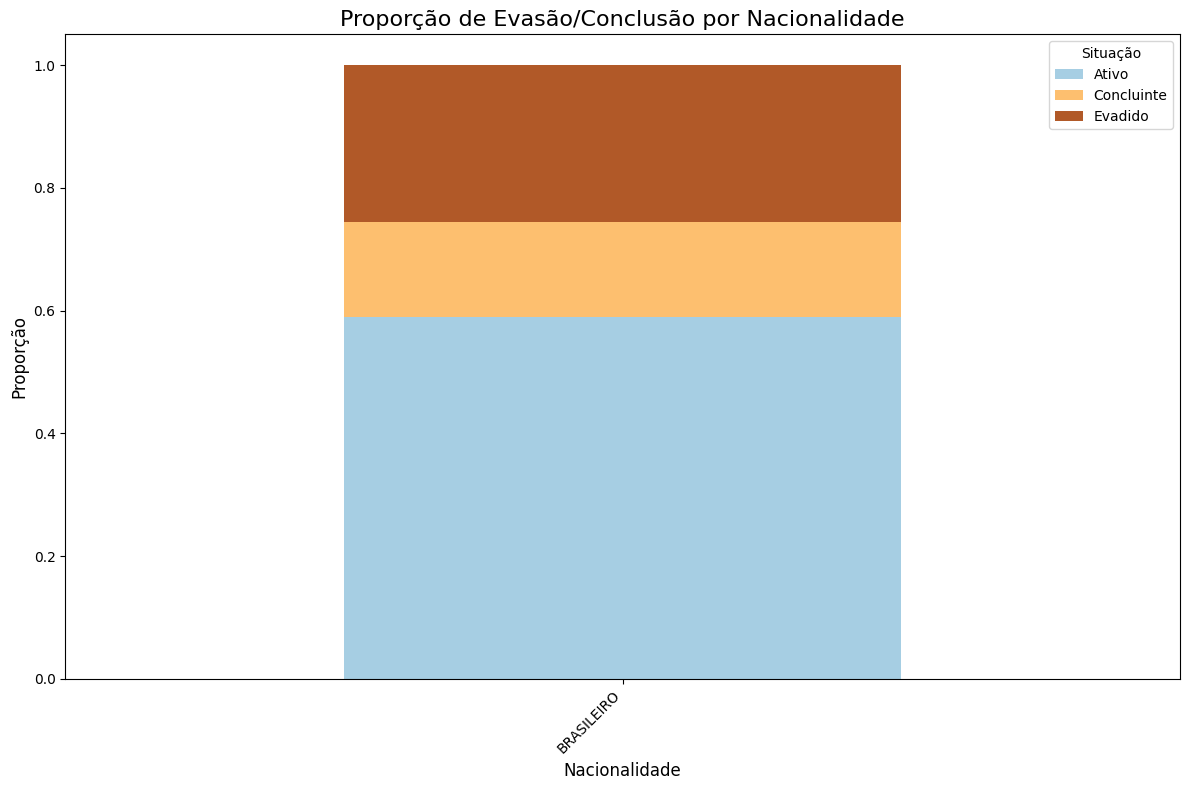

In [ ]:
# Gráfico da proporção de Evasaõ vs Conclusão por Nacionalidade
nacionalidade_evasao = df_unificado.groupby('nacionalidade')['Categoria'].value_counts(normalize=True).unstack().fillna(0)
nacionalidade_evasao = nacionalidade_evasao[['Ativo', 'Concluinte', 'Evadido']]

nacionalidade_evasao.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='Paired')
plt.title('Proporção de Evasão/Conclusão por Nacionalidade', fontsize=16)
plt.xlabel('Nacionalidade', fontsize=12)
plt.ylabel('Proporção', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Situação')
plt.tight_layout()
plt.show()

### 2.3 - Análise de correlação entre coeficiente de rendimento e evasão.

In [ ]:
# Converte a coluna 'Coeficiente' para tipo numérico
df_unificado['coeficiente'] = pd.to_numeric(df_unificado['coeficiente'], errors='coerce')



# Filtra o DataFrame para incluir apenas os alunos Concluintes e Evadidos
df_finalizado = df_analise[df_analise['Categoria'].isin(['Concluinte', 'Evadido'])].copy()


# Compara o Coeficiente médio dos dois grupos
media_evadidos = df_finalizado[df_finalizado['Categoria'] == 'Evadido']['coeficiente'].mean()
media_concluintes = df_finalizado[df_finalizado['Categoria'] == 'Concluinte']['coeficiente'].mean()


print(f"Coeficiente médio dos alunos evadidos: {media_evadidos:.2f}")
print(f"Coeficiente médio dos alunos concluintes: {media_concluintes:.2f}")

Coeficiente médio dos alunos evadidos: 2.13
Coeficiente médio dos alunos concluintes: 6.40


/tmp/ipykernel_582/2044004902.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_finalizado, x='Categoria', y='coeficiente', palette='pastel')


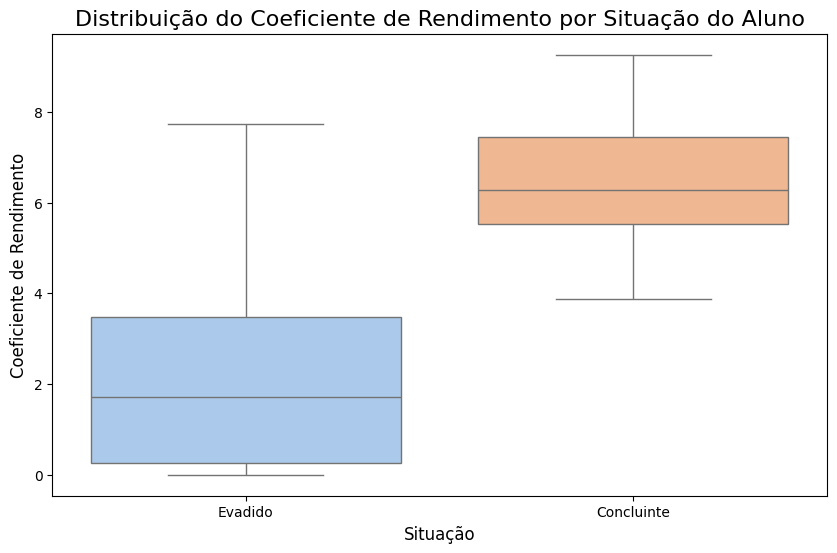

In [ ]:
# Criar um box plot para visualizar a distribuição do Coeficiente por situação do aluno
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_finalizado, x='Categoria', y='coeficiente', palette='pastel')
plt.title('Distribuição do Coeficiente de Rendimento por Situação do Aluno', fontsize=16)
plt.xlabel('Situação', fontsize=12)
plt.ylabel('Coeficiente de Rendimento', fontsize=12)
plt.show()

## 3. Tragetária Acadêmica

### 3.1 - Taxa média de aprovação/reprovação por disciplina.

In [ ]:
# Exibir as primeiras linhas 
print(histEscolar.head())

      Ano    Código                               Nome da Disciplina  CH  CR  \
0  2010/1  72100022                        FUNDAMENTOS DE MATEMÁTICA  64   4   
1  2010/1  72100023                   GEOMETRIA ANALÍTICA E VETORIAL  96   6   
2  2010/1  70400377  Lógica Matemática e Elementos de Lógica Digital  96   6   
3  2010/1  70400375                                    Programação I  96   6   
4  2010/1  72000016         Práticas de Leitura e Produção de Textos  96   6   

   TU   MF  FA  SF  SE                                        rga_anonimo  \
0  CC  3.3   6  RM   1  e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...   
1  CC  5.0   0  AP   1  e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...   
2  CC  5.0   0  AP   1  e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...   
3  CC  4.6   4  RM   1  e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...   
4  CC  7.1   4  AP   1  e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...   

                                Disciplina  \
0         

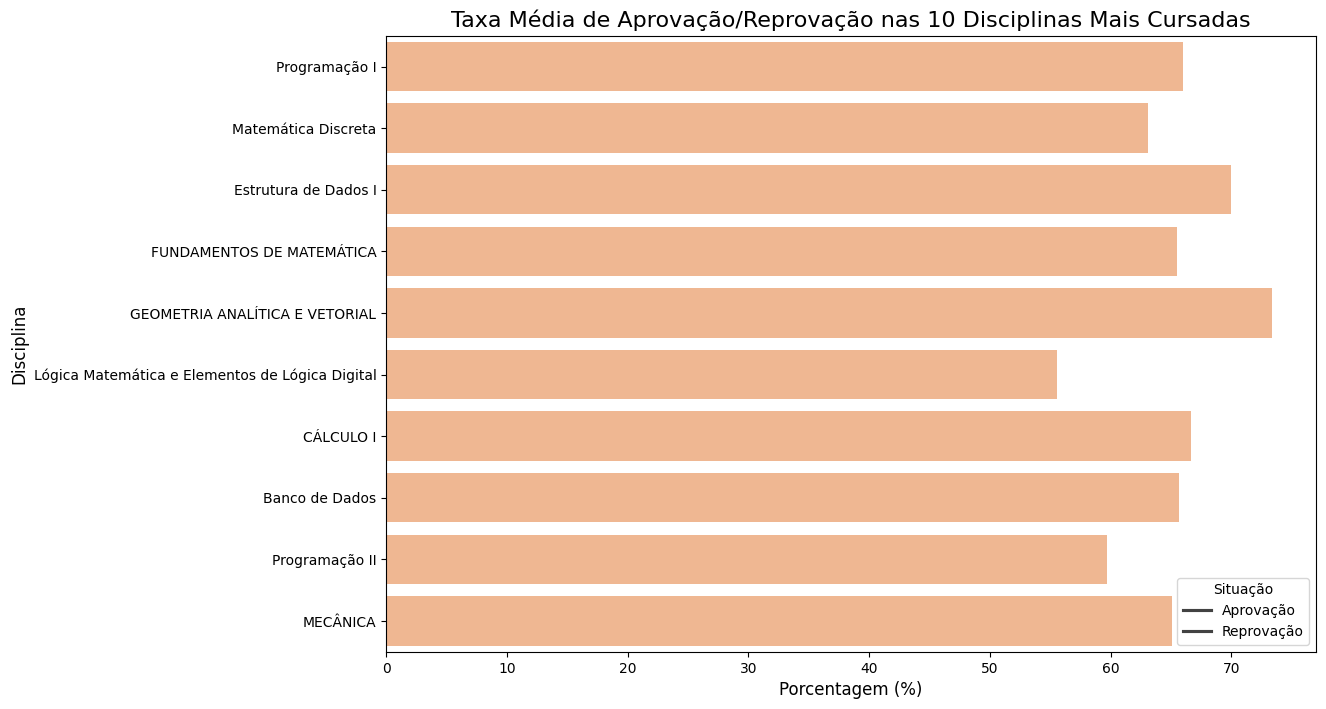

In [ ]:
# Criar uma coluna para a situação de aprovação
histEscolar['Aprovado'] = histEscolar['SF'].apply(lambda x: 1 if x == 'AP' else 0)



# Agrupar por disciplina e calcular o total de alunos e de aprovados
df_disciplinas_aprovacao = histEscolar.groupby('Nome da Disciplina').agg(
    total_alunos=('rga_anonimo', 'count'),
    total_aprovados=('Aprovado', 'sum')
).reset_index()


# Calcular a taxa de aprovação e reprovação por disciplina
df_disciplinas = histEscolar.groupby('Nome da Disciplina').agg(
    total_alunos=('rga_anonimo', 'count'),
    total_aprovados=('Aprovado', 'sum')
).reset_index()

df_disciplinas['taxa_aprovacao'] = (df_disciplinas['total_aprovados'] / df_disciplinas['total_alunos']) * 100
df_disciplinas['taxa_reprovacao'] = 100 - df_disciplinas['taxa_aprovacao']



# Selecionar as 10 disciplinas mais cursadas 
disciplinas_populares = df_disciplinas.sort_values(by='total_alunos', ascending=False).head(10)



# Preparar os dados para o gráfico
df_plot = disciplinas_populares.melt(id_vars='Nome da Disciplina', value_vars=['taxa_aprovacao', 'taxa_reprovacao'],
                                     var_name='Situação', value_name='Taxa')



# Gráfico da taxa de aprovação/reprovação das 10 disciplinas mais cursadas
plt.figure(figsize=(12, 8))
sns.barplot(data=df_plot, x='Taxa', y='Nome da Disciplina', hue='Situação', dodge=False, palette= 'pastel')
plt.title('Taxa Média de Aprovação/Reprovação nas 10 Disciplinas Mais Cursadas', fontsize=16)
plt.xlabel('Porcentagem (%)', fontsize=12)
plt.ylabel('Disciplina', fontsize=12)
plt.legend(title='Situação', labels=['Aprovação', 'Reprovação'])
plt.show()


### 3.2 - Identificação de disciplinas gargalo (com maior índice de reprovação).

Top 10 Disciplinas com Maior Taxa de Reprovação:
                           Nome da Disciplina  total_alunos  taxa_reprovacao
5                   Atividades Complementares           136            100.0
10             Computadores e Sociedade (Opt)             1            100.0
8                    COMPUTADORES E SOCIEDADE             3            100.0
7                                   CALCULO I             3            100.0
63  Introdução à Sistemas de Informação (Opt)            68            100.0
45            Fundamentos de Matemática (Opt)            81            100.0
47               Física II (Eletromagnetismo)             1            100.0
54                        Inglês Instrumental             5            100.0
37     Equações Diferenciais Ordinárias (Opt)             1            100.0
32                        ESTATISTICA GERAL *             1            100.0


/tmp/ipykernel_582/1823948550.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=disciplinas_gargalo, x='taxa_reprovacao', y='Nome da Disciplina', palette= 'pastel')


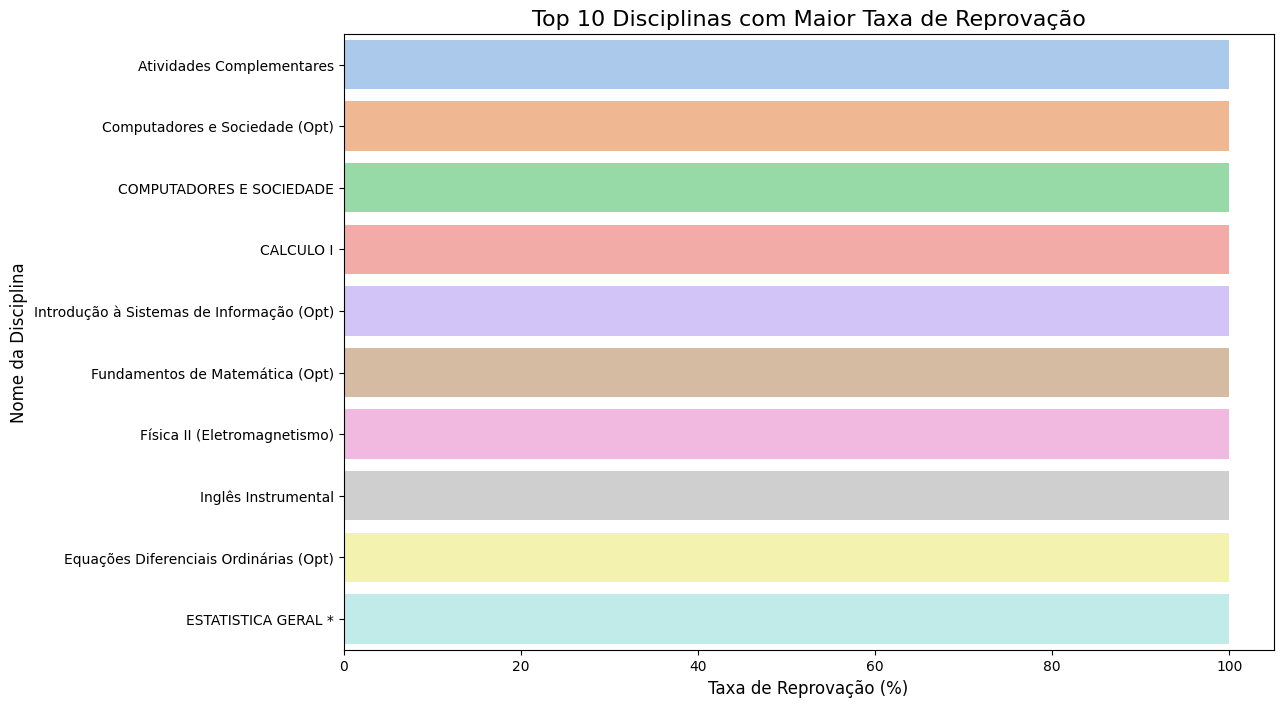

In [ ]:
# Agrupar por disciplina e calcular o total de alunos e de reprovações
df_disciplinas = histEscolar.groupby('Nome da Disciplina').agg(
    total_alunos=('rga_anonimo', 'count'),
    total_reprovados=('Aprovado', lambda x: (x == 0).sum())
).reset_index()



# Calcular a taxa de reprovação em porcentagem
df_disciplinas['taxa_reprovacao'] = (df_disciplinas['total_reprovados'] / df_disciplinas['total_alunos']) * 100



# Selecionar as 10 disciplinas com maior taxa de reprovação
disciplinas_gargalo = df_disciplinas.sort_values(by='taxa_reprovacao', ascending=False).head(10)



# Exibir a tabela das top 10 disciplinas com maior taxa de reprovação
print("Top 10 Disciplinas com Maior Taxa de Reprovação:")
print(disciplinas_gargalo[['Nome da Disciplina', 'total_alunos', 'taxa_reprovacao']].round(2))



# Criar um gráfico de barras para visualizar as disciplinas gargalo
plt.figure(figsize=(12, 8))
sns.barplot(data=disciplinas_gargalo, x='taxa_reprovacao', y='Nome da Disciplina', palette= 'pastel')
plt.title('Top 10 Disciplinas com Maior Taxa de Reprovação', fontsize=16)
plt.xlabel('Taxa de Reprovação (%)', fontsize=12)
plt.ylabel('Nome da Disciplina', fontsize=12)
plt.show()

### 3.3 - Evolução do desempenho do aluno por período (notas e faltas).

In [ ]:
# Criar a coluna de categoria (Evadido, Concluinte, Ativo)
df_unificado['Categoria'] = df_unificado['situação_atual'].apply(
    lambda x: 'Concluinte' if 'FORMADO' in str(x) else ('Evadido' if 'EXCLUSÃO' in str(x) else 'Ativo')
)


# Unificar os dados dos alunos com o histórico escolar
df_completo = pd.merge(histEscolar, df_unificado[['rga_anonimo', 'Categoria']], on='rga_anonimo', how='left')



# Exibir as primeiras linhas para verificar
print(df_completo.head())

      Ano    Código                               Nome da Disciplina  CH  CR  \
0  2010/1  72100022                        FUNDAMENTOS DE MATEMÁTICA  64   4   
1  2010/1  72100023                   GEOMETRIA ANALÍTICA E VETORIAL  96   6   
2  2010/1  70400377  Lógica Matemática e Elementos de Lógica Digital  96   6   
3  2010/1  70400375                                    Programação I  96   6   
4  2010/1  72000016         Práticas de Leitura e Produção de Textos  96   6   

   TU   MF  FA  SF  SE                                        rga_anonimo  \
0  CC  3.3   6  RM   1  e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...   
1  CC  5.0   0  AP   1  e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...   
2  CC  5.0   0  AP   1  e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...   
3  CC  4.6   4  RM   1  e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...   
4  CC  7.1   4  AP   1  e5e493dcefc7ef7a5ca262f82e344b7e505c5299838949...   

                                Disciplina  \
0         

In [ ]:
# Converter as colunas para o tipo numérico (caso não estejam)
df_completo['MF'] = pd.to_numeric(df_completo['MF'], errors='coerce')
df_completo['FA'] = pd.to_numeric(df_completo['FA'], errors='coerce')
df_completo['SE'] = pd.to_numeric(df_completo['SE'], errors='coerce')


# Calcular o desempenho médio (nota e faltas) por semestre e categoria
df_desempenho_semestre = df_completo.groupby(['Categoria', 'SE']).agg(
    media_nota=('MF', 'mean'),
    media_faltas=('FA', 'mean')
).reset_index()



# Exibir os resultados para conferência
print(df_desempenho_semestre.head(10))

    Categoria  SE  media_nota  media_faltas
0       Ativo   0    4.365736     13.773159
1       Ativo   1    3.990466     14.460855
2       Ativo   2    3.241686     17.187199
3       Ativo   3    4.409961      7.854545
4       Ativo   4    3.278938      8.787627
5       Ativo   5    4.842390      9.332696
6       Ativo   6    4.654069      8.101064
7       Ativo   7    5.243386      6.092551
8       Ativo   8    0.578571      5.500000
9  Concluinte   0    6.048711      7.997537


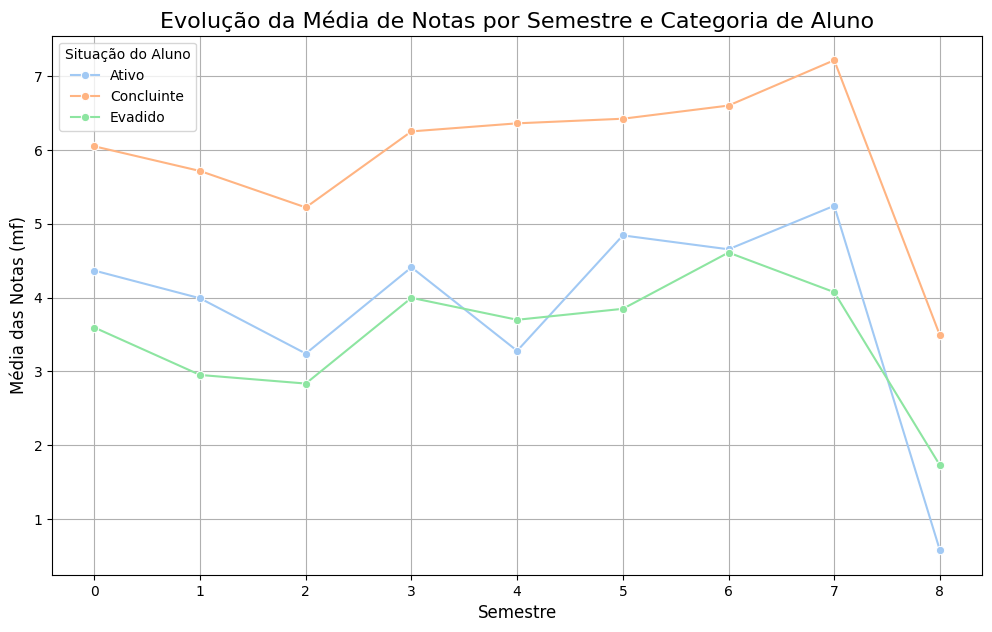

In [ ]:
# Gráfico de evolução da média de notas
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_desempenho_semestre, x='SE', y='media_nota', hue='Categoria', marker='o', palette='pastel')
plt.title('Evolução da Média de Notas por Semestre e Categoria de Aluno', fontsize=16)
plt.xlabel('Semestre', fontsize=12)
plt.ylabel('Média das Notas (mf)', fontsize=12)
plt.xticks(df_desempenho_semestre['SE'].unique())
plt.grid(True)
plt.legend(title='Situação do Aluno')
plt.show()

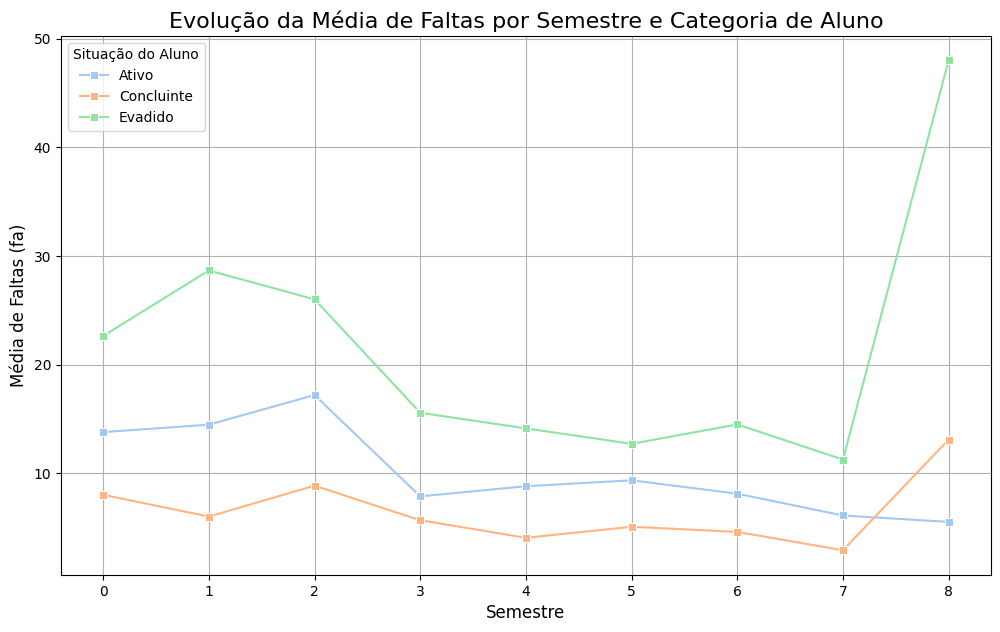

In [ ]:
# Gráfico de Evolução da Média de Faltas por Semestre
# Gráfico de evolução da média de faltas
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_desempenho_semestre, x='SE', y='media_faltas', hue='Categoria', marker='s', palette='pastel')
plt.title('Evolução da Média de Faltas por Semestre e Categoria de Aluno', fontsize=16)
plt.xlabel('Semestre', fontsize=12)
plt.ylabel('Média de Faltas (fa)', fontsize=12)
plt.xticks(df_desempenho_semestre['SE'].unique())
plt.grid(True)
plt.legend(title='Situação do Aluno')
plt.show()


### 3.4 - Relação entre reprovações acumuladas e evasão.

In [ ]:
# Unificar o histórico escolar com a categoria do aluno
df_completo = pd.merge(histEscolar, df_unificado[['rga_anonimo', 'Categoria']], on='rga_anonimo', how='left')



# Definir quais situações finais são consideradas reprovações
reprovacoes = ['RM', 'RF', 'RE']


# Criar uma coluna 'Reprovado'
df_completo['Reprovado'] = df_completo['SF'].apply(lambda x: 1 if x in reprovacoes else 0)


# Calcular o total de reprovações por aluno
df_reprovacoes_por_aluno = df_completo.groupby('rga_anonimo').agg(
    total_reprovacoes=('Reprovado', 'sum')
).reset_index()



# Unificar o total de reprovações com a categoria do aluno
df_final_reprovacoes = pd.merge(df_reprovacoes_por_aluno, df_unificado[['rga_anonimo', 'Categoria']], on='rga_anonimo', how='left')



# Filtrar para incluir apenas Concluintes e Evadidos na análise
df_final_reprovacoes_filtrado = df_final_reprovacoes[df_final_reprovacoes['Categoria'].isin(['Concluinte', 'Evadido'])].copy()



# Exibir as médias de reprovações
media_reprovacoes_evadidos = df_final_reprovacoes_filtrado[df_final_reprovacoes_filtrado['Categoria'] == 'Evadido']['total_reprovacoes'].mean()
media_reprovacoes_concluintes = df_final_reprovacoes_filtrado[df_final_reprovacoes_filtrado['Categoria'] == 'Concluinte']['total_reprovacoes'].mean()

print(f"Média de reprovações de alunos evadidos: {media_reprovacoes_evadidos:.2f}")
print(f"Média de reprovações de alunos concluintes: {media_reprovacoes_concluintes:.2f}")


Média de reprovações de alunos evadidos: 6.23
Média de reprovações de alunos concluintes: 6.13


/tmp/ipykernel_582/766925831.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final_reprovacoes_filtrado, x='Categoria', y='total_reprovacoes', palette='pastel')


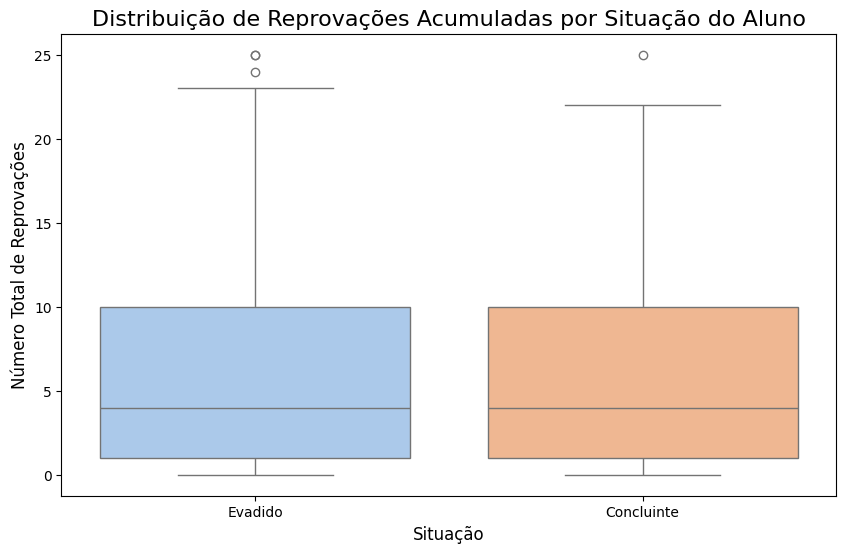

In [ ]:
# Criar um box plot para visualizar a distribuição
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final_reprovacoes_filtrado, x='Categoria', y='total_reprovacoes', palette='pastel')
plt.title('Distribuição de Reprovações Acumuladas por Situação do Aluno', fontsize=16)
plt.xlabel('Situação', fontsize=12)
plt.ylabel('Número Total de Reprovações', fontsize=12)
plt.show()

## 4. Comparação entre grupos

### 4.1 - Diferenças no coeficiente de rendimento por sexo, raça, tipo de ingresso.

/tmp/ipykernel_582/2844636585.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_unificado, x='sexo', y='coeficiente', palette='pastel')


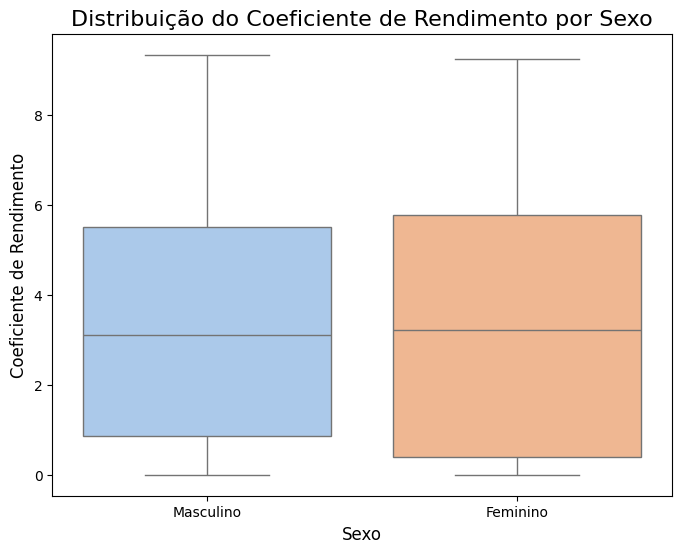

Coeficiente Médio por Sexo:
sexo
Feminino     3.280932
Masculino    3.331867
Name: coeficiente, dtype: float64


In [ ]:
# Análise de CR por Sexo
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_unificado, x='sexo', y='coeficiente', palette='pastel')
plt.title('Distribuição do Coeficiente de Rendimento por Sexo', fontsize=16)
plt.xlabel('Sexo', fontsize=12)
plt.ylabel('Coeficiente de Rendimento', fontsize=12)
plt.show()

media_cr_sexo = df_unificado.groupby('sexo')['coeficiente'].mean()
print("Coeficiente Médio por Sexo:")
print(media_cr_sexo)

/tmp/ipykernel_582/3652517510.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_unificado, x='raça', y='coeficiente', palette='pastel')


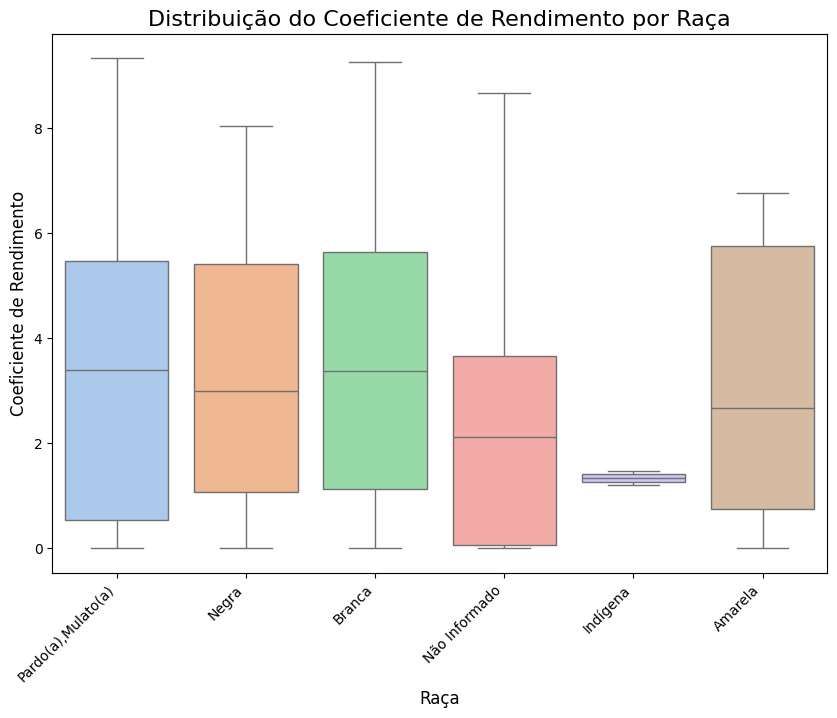

Coeficiente Médio por Raça:
raça
Amarela               3.106842
Branca                3.489493
Indígena              1.340000
Negra                 3.249194
Não Informado         2.606200
Pardo(a),Mulato(a)    3.321488
Name: coeficiente, dtype: float64


In [ ]:
# Análise de CR por Raça
plt.figure(figsize=(10, 7))
sns.boxplot(data=df_unificado, x='raça', y='coeficiente', palette='pastel')
plt.title('Distribuição do Coeficiente de Rendimento por Raça', fontsize=16)
plt.xlabel('Raça', fontsize=12)
plt.ylabel('Coeficiente de Rendimento', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

media_cr_raca = df_unificado.groupby('raça')['coeficiente'].mean()
print("Coeficiente Médio por Raça:")
print(media_cr_raca)

/tmp/ipykernel_582/2452047782.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_unificado, x='tipo_ingresso', y='coeficiente', palette='pastel')


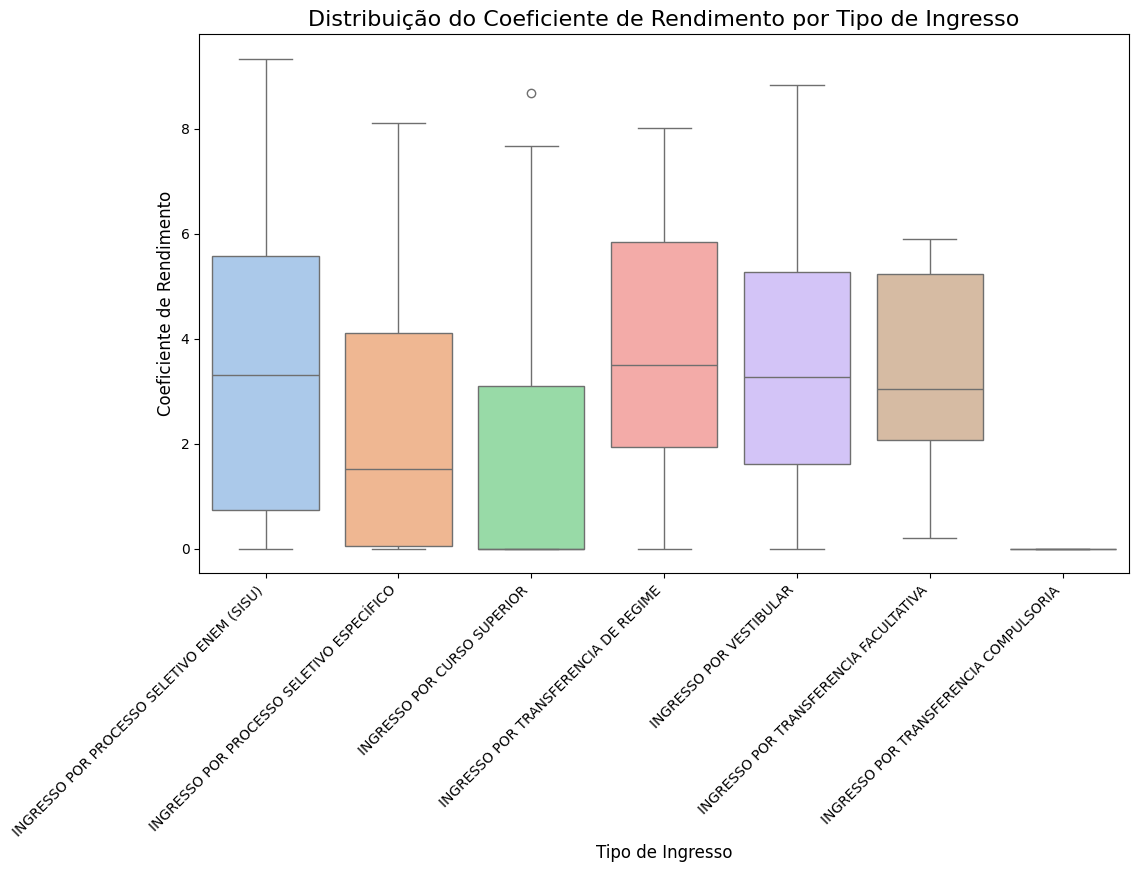

Coeficiente Médio por Tipo de Ingresso:
tipo_ingresso
INGRESSO POR CURSO SUPERIOR                   2.185455
INGRESSO POR PROCESSO SELETIVO ENEM (SISU)    3.380584
INGRESSO POR PROCESSO SELETIVO ESPECÍFICO     2.451892
INGRESSO POR TRANSFERENCIA COMPULSORIA        0.000000
INGRESSO POR TRANSFERENCIA DE REGIME          3.724545
INGRESSO POR TRANSFERENCIA FACULTATIVA        3.315000
INGRESSO POR VESTIBULAR                       3.358542
Name: coeficiente, dtype: float64


In [ ]:
# Análise de CR por Tipo de Ingresso
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_unificado, x='tipo_ingresso', y='coeficiente', palette='pastel')
plt.title('Distribuição do Coeficiente de Rendimento por Tipo de Ingresso', fontsize=16)
plt.xlabel('Tipo de Ingresso', fontsize=12)
plt.ylabel('Coeficiente de Rendimento', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

media_cr_ingresso = df_unificado.groupby('tipo_ingresso')['coeficiente'].mean()
print("Coeficiente Médio por Tipo de Ingresso:")
print(media_cr_ingresso)

### 4.2 - Diferença entre evasão por forma de ingresso (ENEM, transferência, e tipos de Cotas).


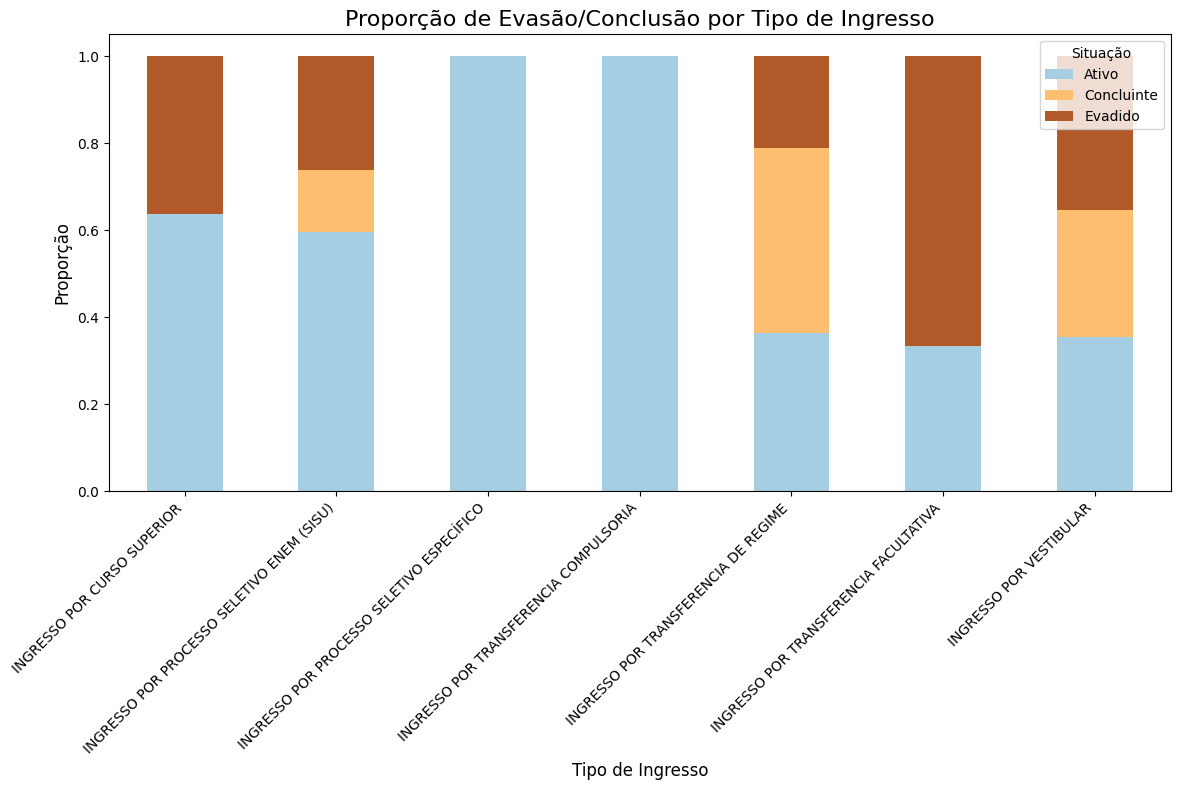

In [ ]:
# Calcular a proporção de evasão por tipo de ingresso
df_ingresso_evasao = df_unificado.groupby('tipo_ingresso')['Categoria'].value_counts(normalize=True).unstack().fillna(0)


# Reordenar as colunas para que o gráfico seja mais claro
if 'Ativo' in df_ingresso_evasao.columns:
    colunas_ordenadas = ['Ativo', 'Concluinte', 'Evadido']
    df_ingresso_evasao = df_ingresso_evasao.reindex(columns=colunas_ordenadas, fill_value=0)



# Crie um gráfico de barras empilhadas
df_ingresso_evasao.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='Paired')
plt.title('Proporção de Evasão/Conclusão por Tipo de Ingresso', fontsize=16)
plt.xlabel('Tipo de Ingresso', fontsize=12)
plt.ylabel('Proporção', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Situação')
plt.tight_layout()
plt.show()

<a id='teste'></a>
## 5. Testes estatísticos recomendados

### Merge
Antes de realizar os testes precisamos agrupar os alunos ativos e inativos para diferenciar quem é evadido e quem é concluinte.

In [ ]:
# Adicionar coluna de status (Ativo/Inativo)
alunosAtivos['Status'] = 'Ativo'
alunosInativos['Status'] = 'Inativo'

# Combinar os datasets de alunos ativos e inativos
alunos = pd.concat([alunosAtivos, alunosInativos], ignore_index=True)

# Padronizar os valores da situação
alunos['situação_atual'] = alunos['situação_atual'].str.upper()

# Classificar a situação em Concluinte, Evadido ou Cursando
def classificar_situacao(situacao):
    if 'CONCLUSAO' in situacao:
        return 'Concluinte'
    elif 'DESLIGAMENTO' in situacao or 'DESISTENCIA' in situacao:
        return 'Evadido'
    else:
        return 'Cursando'

alunos['Grupo'] = alunos['situação_atual'].apply(classificar_situacao)

# Calcular número total de faltas por aluno
faltas_por_aluno = histEscolar.groupby('rga_anonimo')['FA'].sum().reset_index()
faltas_por_aluno.rename(columns={'FA': 'Total_Faltas'}, inplace=True)

# Unir total de faltas com dataset principal
alunos_merged = alunos.merge(faltas_por_aluno, on='rga_anonimo', how='left')

# Visualizar resultado
alunos_merged.head()


,data_nascimento,sexo,raça,estrangeiro,nacionalidade,naturalidade,uf_naturalidade,período,situação_atual,data_ocorrência,...,período_ingresso,tipo_ingresso,imi,coeficiente,tipo_de_demanda,rga_anonimo,status,Status,Grupo,Total_Faltas
0,2000-01-14,Masculino,"Pardo(a),Mulato(a)",Não,BRASILEIRO,ARAGARCAS,GO,20232,MATRICULADO NO PERÍODO,2023-11-16,...,20181,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),56.7,5.49,L6 - Estudante preto pardo ou indígena de esco...,af05b362ddb9224c4589b23cbf119b60ce7e26300b6a3a...,ativo,Ativo,Cursando,153.0
1,1997-04-26,Masculino,"Pardo(a),Mulato(a)",Não,BRASILEIRO,SAO JOSE DO JACUIPE,BA,20232,AFASTAMENTO POR BLOQUEIO DE MATRICULA,2023-11-10,...,20171,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),35.8,4.42,Ampla Concorrência,208844f5f871e3b92a344f0a6f7782b209872e5667ea13...,ativo,Ativo,Cursando,854.0
2,1999-09-04,Masculino,Negra,Não,BRASILEIRO,BARRA DO GARCAS,MT,20232,MATRICULADO NO PERÍODO,2023-12-01,...,20171,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),50.1,5.93,Ampla Concorrência,157770a9bd112bd511d5fed47b295121e2be2e9d082f84...,ativo,Ativo,Cursando,470.0
3,1994-06-05,Masculino,"Pardo(a),Mulato(a)",Não,BRASILEIRO,SAO JOSÉ DO XINGU,MT,20232,AFASTAMENTO POR BLOQUEIO DE MATRICULA,2023-11-10,...,20131,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),59.7,7.03,L4 - Estudante preto pardo ou indígena de esco...,71260f57df37913cf04b8a5f882737c071c9313b201158...,ativo,Ativo,Cursando,508.0
4,2004-05-24,Feminino,Branca,Não,BRASILEIRO,GOIANIA,GO,20232,AFASTAMENTO POR TRANCAMENTO DE MATRICULA,2023-11-30,...,20221,INGRESSO POR PROCESSO SELETIVO ESPECÍFICO,50.8,4.78,Ampla Concorrência,d517234d3868dee3fc27d4ff1dee463e9d68b45d51ad22...,ativo,Ativo,Cursando,63.0


<a id='media'></a>
### 5.1. Comparações de média
- **t-Teste de Student (independente)** → comparar coeficiente de rendimento médio entre **evadidos e concluintes.**

Tamanho do grupo Evadidos: 169
Tamanho do grupo Concluintes: 111


Text(0, 0.5, 'Frequência')

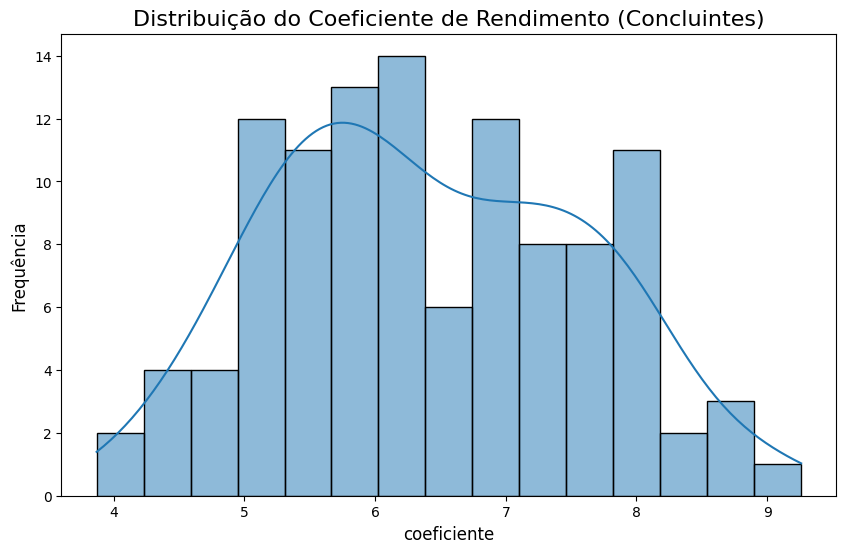

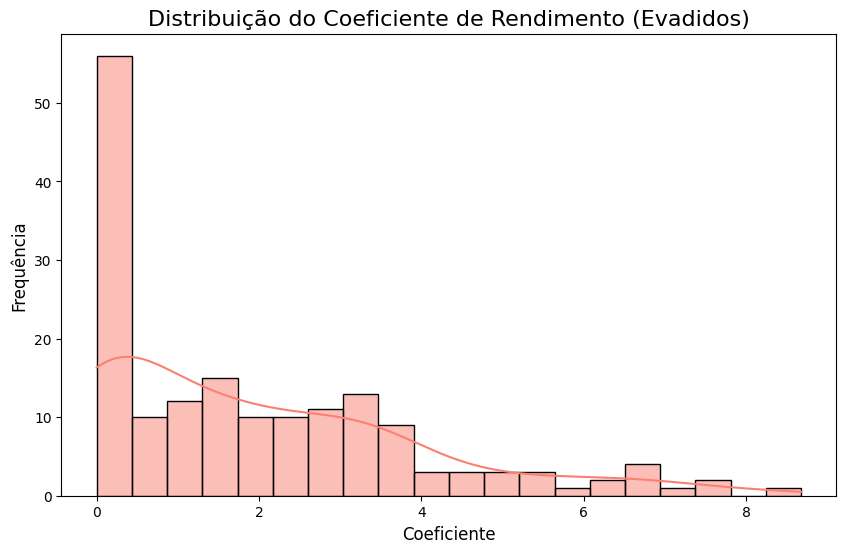

In [ ]:
# Separar os grupos
evadidos = alunos_merged[alunos_merged['Grupo'] == 'Evadido']['coeficiente'].dropna()
concluintes = alunos_merged[alunos_merged['Grupo'] == 'Concluinte']['coeficiente'].dropna()

#contar o tamnanho dos grupos
print(f"Tamanho do grupo Evadidos: {len(evadidos)}")
print(f"Tamanho do grupo Concluintes: {len(concluintes)}")  

# Separar os dados em duas amostras
coef_concluintes = alunos[alunos['Grupo'] == 'Concluinte']['coeficiente'].dropna()
coef_evadidos = alunos[alunos['Grupo'] == 'Evadido']['coeficiente'].dropna()

# Histograma para Concluintes
plt.figure(figsize=(10, 6))
sns.histplot(coef_concluintes, kde=True, bins=15)
plt.title('Distribuição do Coeficiente de Rendimento (Concluintes)', fontsize=16)
plt.xlabel('coeficiente', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

# Histograma para Evadidos
plt.figure(figsize=(10, 6))
sns.histplot(coef_evadidos, kde=True, bins=20, color='salmon')
plt.title('Distribuição do Coeficiente de Rendimento (Evadidos)', fontsize=16)
plt.xlabel('Coeficiente', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

- **ANOVA (ou Kruskal–Wallis, se não normal)** → comparar rendimento entre diferentes **tipos de ingresso** ou **estruturas curriculares.**

--- Teste de Kruskal-Wallis: Coeficiente por Tipo de Ingresso ---
Estatística do teste: 11.2680
P-valor: 0.0804
Resultado: Não há evidência de uma diferença significativa no Coeficiente entre os diferentes Tipos de Ingresso.


/tmp/ipykernel_582/2811636219.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analise, x='tipo_ingresso', y='coeficiente', palette='viridis')


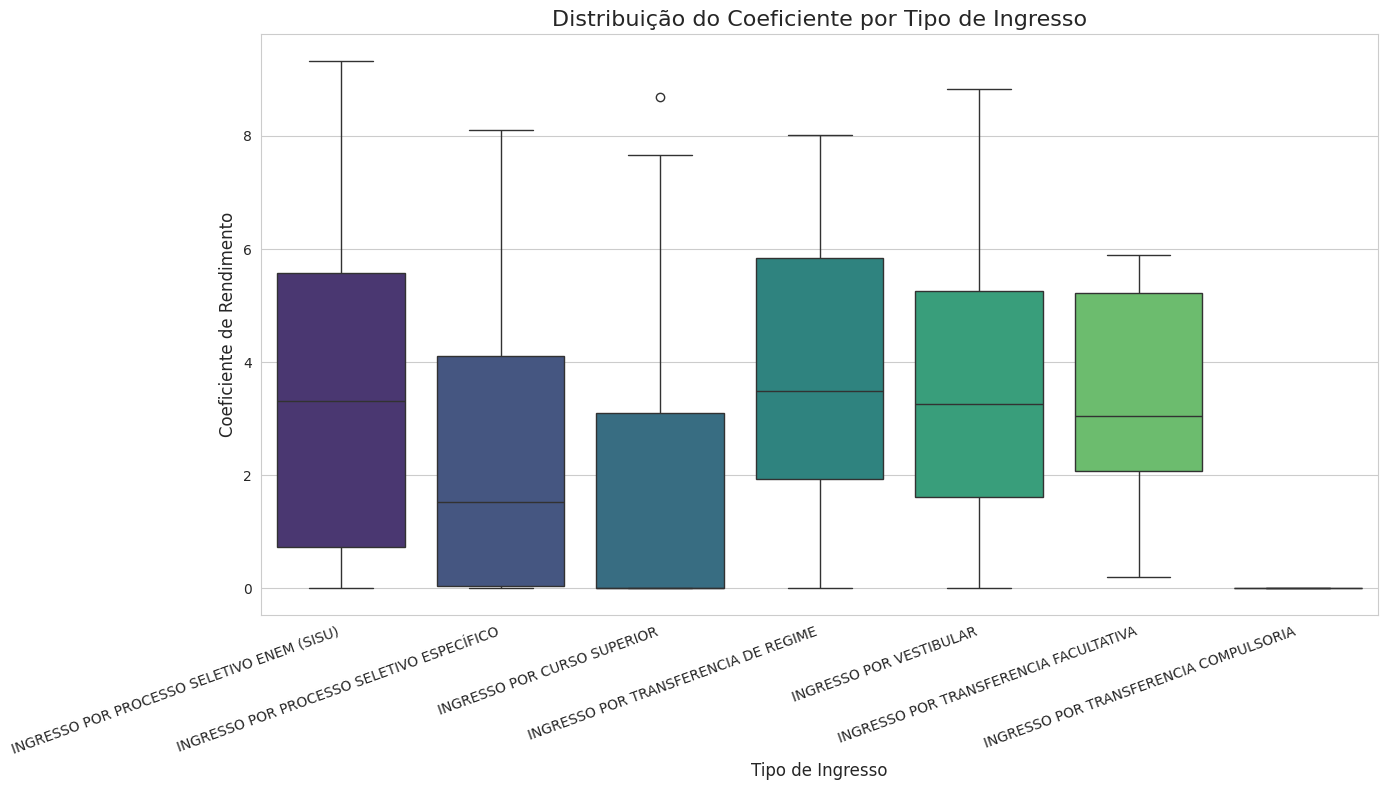

In [ ]:
# Remover linhas onde o coeficiente é nulo para o teste
df_analise = alunos_merged.dropna(subset=['coeficiente', 'tipo_ingresso']).copy()

# Executar o Teste de Kruskal-Wallis pois os dados não seguem uma distribuição normal
# Criar uma lista de amostras de 'Coeficiente' para cada 'Tipo de ingresso'
grupos = [df_analise['coeficiente'][df_analise['tipo_ingresso'] == tipo] for tipo in df_analise['tipo_ingresso'].unique()]

# Executar o teste
statistic, p_value = stats.kruskal(*grupos)

print("--- Teste de Kruskal-Wallis: Coeficiente por Tipo de Ingresso ---")
print(f"Estatística do teste: {statistic:.4f}")
print(f"P-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Resultado: Há uma diferença estatisticamente significativa no Coeficiente entre os diferentes Tipos de Ingresso.")
else:
    print("Resultado: Não há evidência de uma diferença significativa no Coeficiente entre os diferentes Tipos de Ingresso.")

# --- Etapa 3: Criar a Melhor Visualização (Box Plot) ---
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

sns.boxplot(data=df_analise, x='tipo_ingresso', y='coeficiente', palette='viridis')

plt.title('Distribuição do Coeficiente por Tipo de Ingresso', fontsize=16)
plt.xlabel('Tipo de Ingresso', fontsize=12)
plt.ylabel('Coeficiente de Rendimento', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()

<a id='associacao'></a>
### 5.2. Associação entre variáveis categóricas
- **Qui-quadrado de independência** → testar se **evasão está associada a sexo, raça, tipo de ingresso, estado civil.**

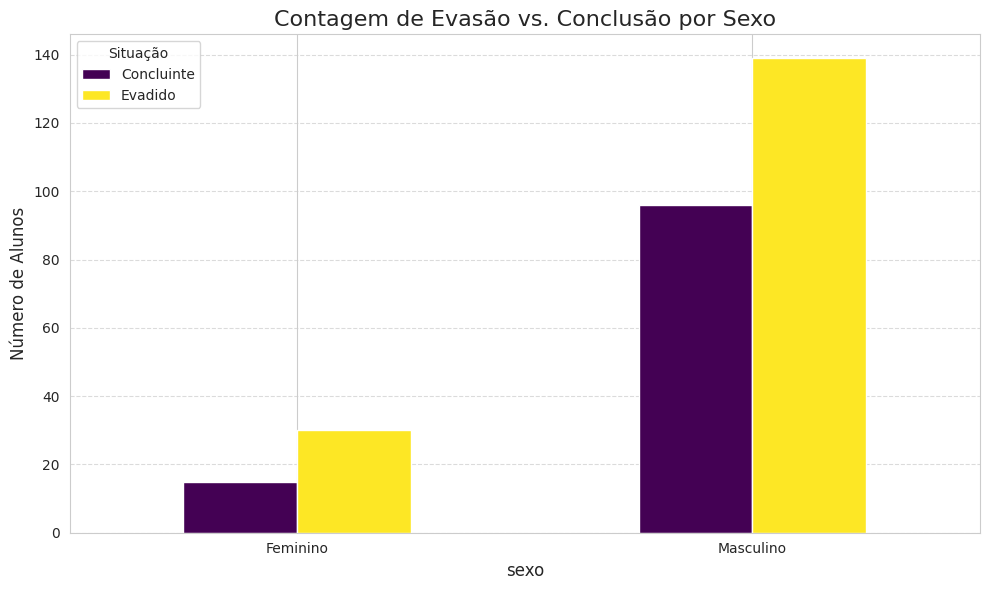

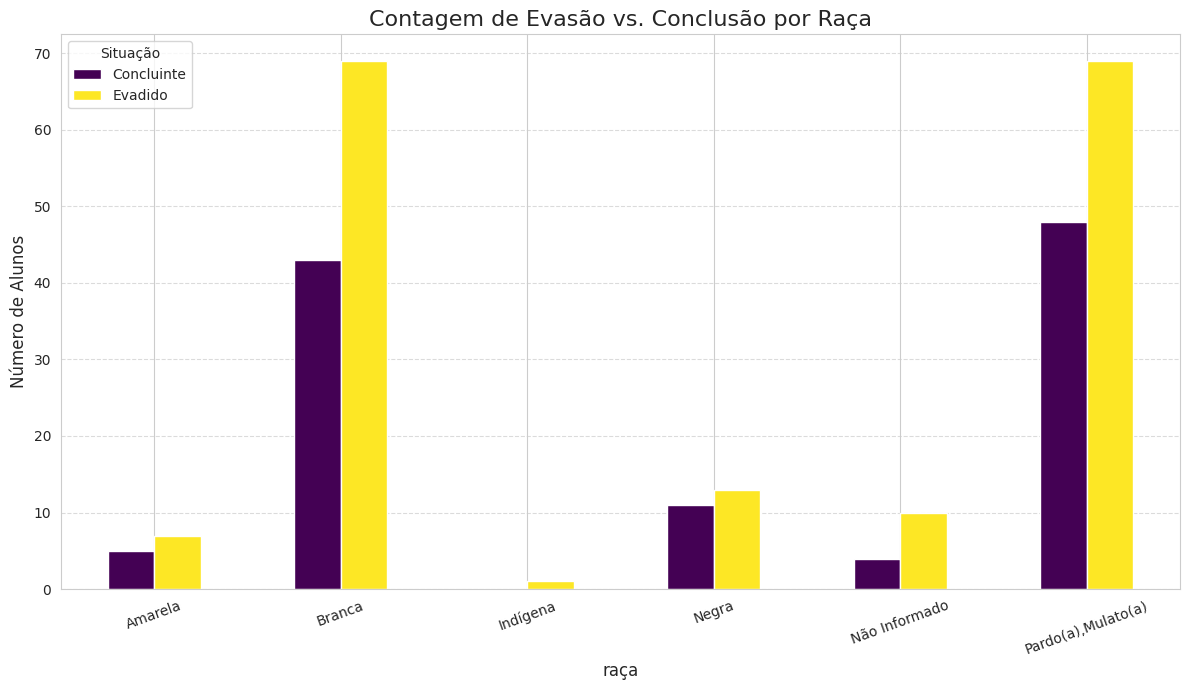

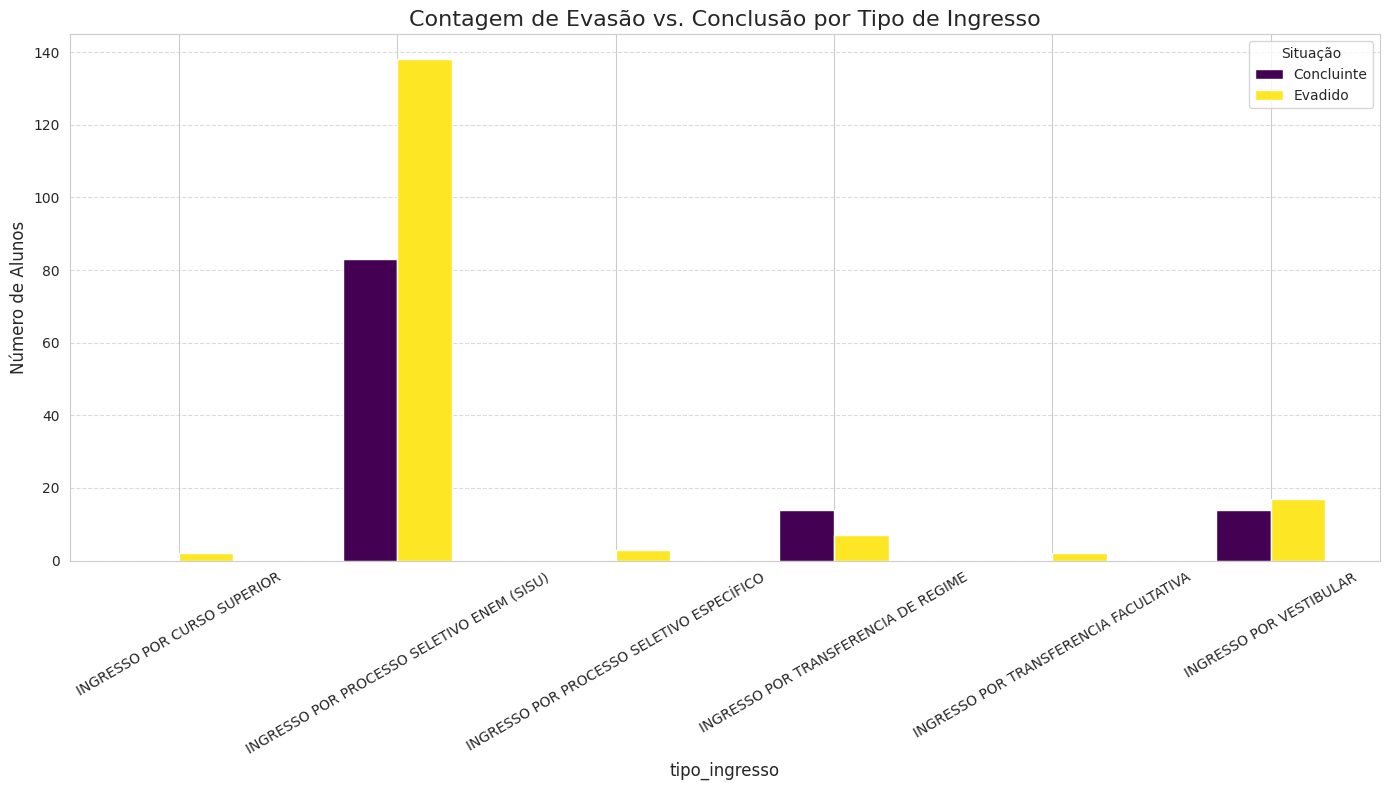

In [ ]:
alunos_merged['SituacaoEvasao'] = alunos_merged['situação_atual'].apply(classificar_situacao)
alunos_merged = alunos_merged[alunos_merged['SituacaoEvasao'].isin(['Evadido', 'Concluinte'])].copy()

# Função para criar os gráficos agrupado

def plot_grouped_bar(column_name, title, figsize=(10, 6), rotation=0): # Essa função cria e salva gráficos de barras agrupadas, passa como parâmetros o nome da coluna, título do gráfico, tamanho da figura e rotação dos rótulos do eixo x
    """Cria um gráfico de barras agrupadas.""" 
    # Cria a tabela de contingência
    contingency_table = pd.crosstab(alunos_merged[column_name], alunos_merged['SituacaoEvasao']) # Tabela cruzada entre a coluna especificada e a situação de evasão
    
    # Cria o gráfico
    contingency_table.plot(kind='bar', stacked=False, figsize=figsize, colormap='viridis')
    
    plt.title(title, fontsize=16)
    plt.xlabel(column_name, fontsize=12)
    plt.ylabel('Número de Alunos', fontsize=12)
    plt.xticks(rotation=rotation)
    plt.legend(title='Situação')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

# Gerar os novos gráficos

# Gráfico para Sexo
plot_grouped_bar('sexo', 'Contagem de Evasão vs. Conclusão por Sexo')

# Gráfico para Raça
plot_grouped_bar('raça', 'Contagem de Evasão vs. Conclusão por Raça', figsize=(12, 7), rotation=20)

# Gráfico para Tipo de Ingresso
plot_grouped_bar('tipo_ingresso', 'Contagem de Evasão vs. Conclusão por Tipo de Ingresso', figsize=(14, 8), rotation=30)

<a id='corr'></a>
### 5.3. Correlação

- **Spearman** → se a relação não for linear ou variáveis ordinais.

In [ ]:
dados_validos = alunos_merged[['coeficiente', 'Total_Faltas']].dropna()
spearman_corr, spearman_p = stats.spearmanr(dados_validos['coeficiente'], dados_validos['Total_Faltas'])
print(f"Correlação de Spearman: r={spearman_corr:.3f}, p={spearman_p:.10f}")

# Interpretação com base no valor de p
if spearman_p < 0.05:
    print("A correlação é estatisticamente significativa.")
else:
    print("A correlação não é estatisticamente significativa.")

Correlação de Spearman: r=-0.368, p=0.0000000007
A correlação é estatisticamente significativa.


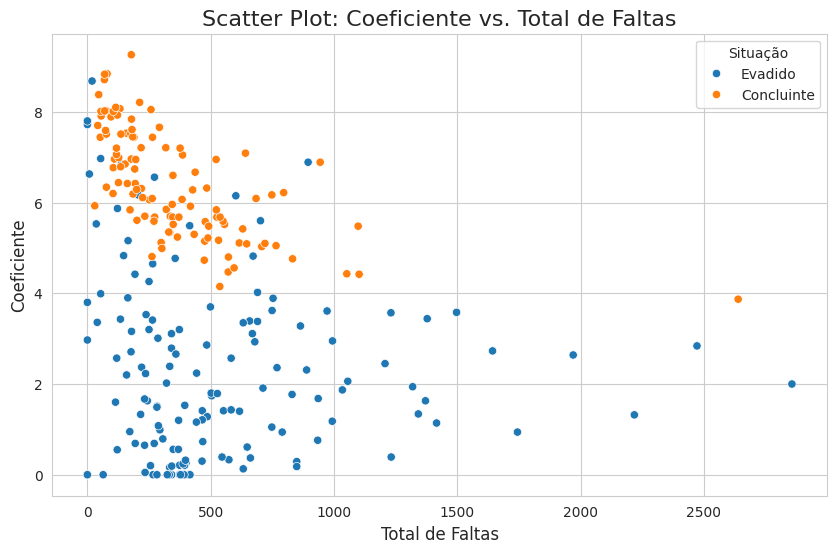

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=alunos_merged, x='Total_Faltas', y='coeficiente', hue='SituacaoEvasao')
plt.title('Scatter Plot: Coeficiente vs. Total de Faltas', fontsize=16)
plt.xlabel('Total de Faltas', fontsize=12)
plt.ylabel('Coeficiente', fontsize=12)
plt.legend(title='Situação')
plt.grid(True)
plt.show()

Revelou que, embora fraca, existe uma relação estatisticamente significativa onde mais Faltas estão associadas a um menor Coeficiente. A visualização foi a prova definitiva, mostrando dois "universos" de alunos: os concluintes agrupados na zona de alto coeficiente e os evadidos na zona de baixo coeficiente.

<a id='comp'></a>
### 5.4. Comparação de distribuições

- Mann-Whitney U → comparar coeficientes entre dois grupos (ex.: evadidos vs concluintes) quando não há normalidade.

 Estrutura: 20091
   Estatística U: 410.00
   Valor-p: 5.3325e-31 (0.000000000000000000000000000000533248153664398)
   → Há diferença significativa entre os coeficientes dos dois grupos.



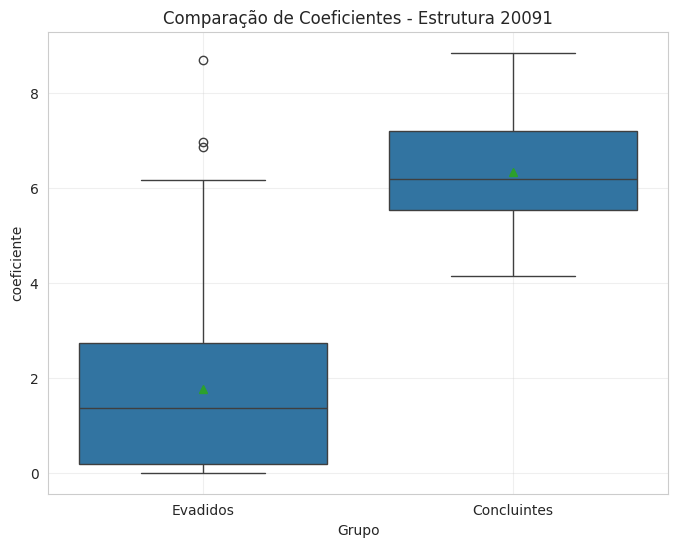

 Estrutura: 20191
   Estatística U: 217.00
   Valor-p: 1.2249e-11 (0.000000000012248848195265661275568003462827795)
   → Há diferença significativa entre os coeficientes dos dois grupos.



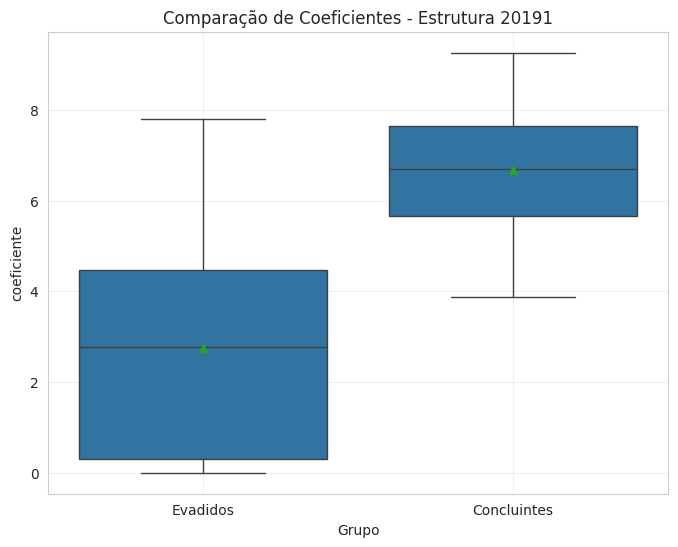

In [ ]:
for estrutura, grupo in alunosInativos.groupby("estrutura"):

    # Filtra evadidos e concluintes dentro do grupo (estrutura atual)
    evadidos = grupo[
        grupo['situação_atual'].str.contains("DESISTENCIA|DESLIGAMENTO|CANCELAMENTO|EXCLUSÃO", case=False, na=False)
        & ~grupo['situação_atual'].str.contains("EXCLUSÃO POR CONCLUSÃO", case=False, na=False)
    ]
    concluintes = grupo[grupo['situação_atual'].str.contains("CONCLUSAO", case=False, na=False)]

    # Seleciona os coeficientes
    coef_evadidos = evadidos['coeficiente'].dropna()
    coef_concluintes = concluintes['coeficiente'].dropna()

    # Só roda o teste se tiver dados nos dois grupos
    if len(coef_evadidos) > 0 and len(coef_concluintes) > 0:
        stat, p = mannwhitneyu(coef_evadidos, coef_concluintes, alternative='two-sided')

        print(f" Estrutura: {estrutura}")
        print(f"   Estatística U: {stat:.2f}")
        print(f"   Valor-p: {p:.4e} ({p:.45f})")
        if p < 0.05:
            print("   → Há diferença significativa entre os coeficientes dos dois grupos.\n")
        else:
            print("   → Não há diferença significativa entre os coeficientes dos dois grupos.\n")

        # --- Prepara dataframe para o gráfico ---
        df_plot = pd.DataFrame({
            "coeficiente": list(coef_evadidos) + list(coef_concluintes),
            "Grupo": (["Evadidos"] * len(coef_evadidos)) + (["Concluintes"] * len(coef_concluintes))
        })

        plt.figure(figsize=(8,6))
        sns.boxplot(x="Grupo", y="coeficiente", data=df_plot, showmeans=True)
        plt.title(f"Comparação de Coeficientes - Estrutura {estrutura}")
        plt.grid(True, alpha=0.3)
        plt.show()

**Conclusões**  
* O teste de Mann-Whitney U apresentou:
    * Estrutura 20091 → U = 410, valor-p ≈ 5.33 × 10⁻³¹.
    * Estrutura 20191 → U = 217, valor-p ≈ 1.22 × 10⁻¹¹.
* Segundo o resultado do teste, há diferenças significativas entre os coeficiente dos alunos evadidos e concluintes (p < 0,05), levando à rejeição da hipótese nula de equivalência entre as médias/medianas entre esses grupos (Em ambas grades).
* Como pode ser vizualizado no boxplot, os alunos evadidos possuem desempenho acadêmico significativamente menor, o que coincide com a hipótese de que coeficientes mais baixos estão associados à evasão. Já os alunos concluintes possuem um desempenho acadêmico superior.
* Por fim, os resultados reforçam a hipótese que a evasão está associada à um rendimento acadêmico inferior.

- Kolmogorov–Smirnov (K-S test) → comparar distribuição de notas de disciplinas entre evadidos e concluintes.

Grade: 20091
   Estatística KS = 0.4730, Valor-p = 0.0000
As distribuições de notas entre evadidos e concluintes são significativamente diferentes.


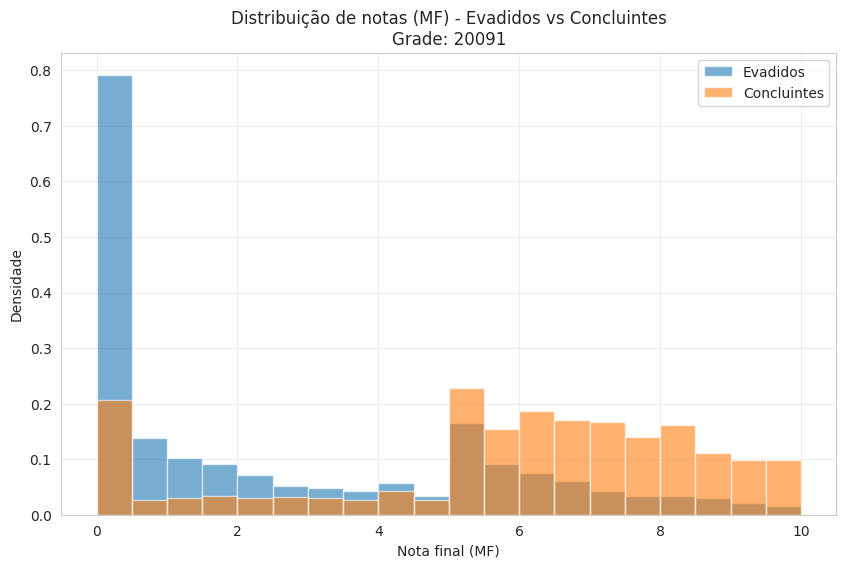

Grade: 20191
   Estatística KS = 0.3126, Valor-p = 0.0000
As distribuições de notas entre evadidos e concluintes são significativamente diferentes.


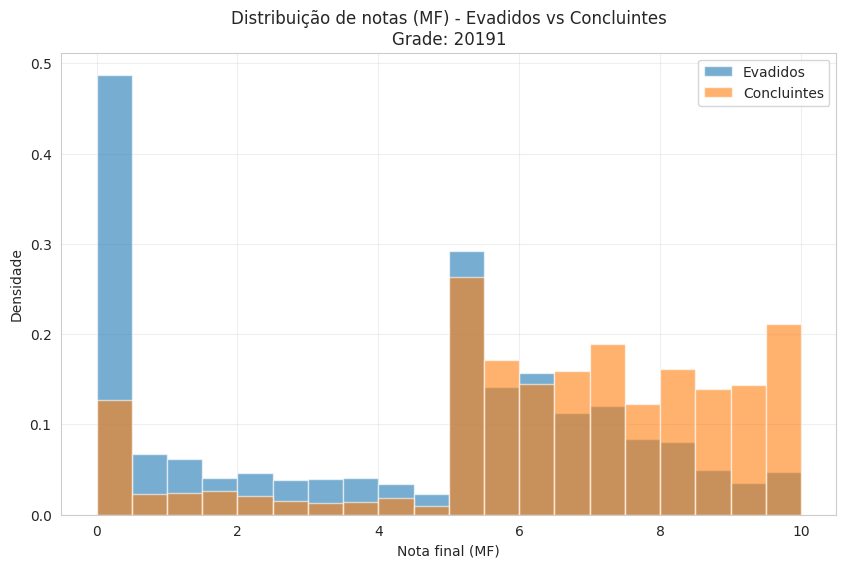

In [ ]:
alunos = pd.concat([alunosAtivos, alunosInativos], ignore_index=True)
# Filtra os grupos na tabela alunos_inativos e alunos_Ativos
evadidos = alunosInativos[
    alunosInativos['situação_atual'].str.contains("DESISTENCIA|DESLIGAMENTO|CANCELAMENTO|EXCLUSÃO", case=False, na=False)
    & ~alunosInativos['situação_atual'].str.contains("EXCLUSÃO POR CONCLUSÃO", case=False, na=False)
]
concluintes = alunosInativos[alunosInativos['situação_atual'].str.contains("CONCLUSAO", case=False, na=False)]

# Junta o histórico escolar com a info de alunos (ativos+inativos)
hist_grade = histEscolar.merge(
    alunos[["rga_anonimo", "estrutura"]],
    on="rga_anonimo",
    how="left"
)
#Distribuição de notas (MF) entre evadidos e concluintes
evadidos_ids = evadidos["rga_anonimo"]
concluintes_ids = concluintes["rga_anonimo"]

for grade, grupo in hist_grade.groupby("estrutura"):
    # Filtrar notas (MF = média final) do histórico
    notas_evadidos = grupo[grupo["rga_anonimo"].isin(evadidos_ids)]["MF"].dropna().astype(float)
    notas_concluintes = grupo[grupo["rga_anonimo"].isin(concluintes_ids)]["MF"].dropna().astype(float)
    # Executar KS-test
    ks_result = ks_2samp(notas_evadidos, notas_concluintes)
    ks_result
    print(f"Grade: {grade}")
    print(f"   Estatística KS = {ks_result.statistic:.4f}, Valor-p = {ks_result.pvalue:.4f}")
    if ks_result.pvalue < 0.05:
        print('As distribuições de notas entre evadidos e concluintes são significativamente diferentes.')
    else:
        print('As distribuições de notas entre evadidos e concluintes não são significativamente diferentes.')

    plt.figure(figsize=(10,6))
    plt.hist(notas_evadidos, bins=20, alpha=0.6, density=True, label="Evadidos")
    plt.hist(notas_concluintes, bins=20, alpha=0.6, density=True, label="Concluintes")

    plt.title(f"Distribuição de notas (MF) - Evadidos vs Concluintes\nGrade: {grade}")
    plt.xlabel("Nota final (MF)")
    plt.ylabel("Densidade")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

**Conclusões**  
* Grade 20091:
    * Estatística KS = 0.4730, Valor-p = 0.0000.
    Isso indica uma diferença forte entre as distribuições de notas. Essa medida indica a distância máxima entre as duas distribuições acumuladas (evadidos vs concluintes). Um valor em torno de 0.47 mostra que as distribuições tem um desvio considerável.
    * Valor-p: 0.0000, logo a hipótese nula de que as distribuições de notas (MF) de evadidos e concluintes são iguais é descartada.


* Grade 20191:
    * Estatística KS = 0.3126, Valor-p = 0.0000.
    Aqui também há diferença significativa, mas um pouco menor que na grade 20091. Essa medida indica a distância máxima entre as duas distribuições acumuladas (evadidos vs concluintes). Um valor em torno de 0.31 mostra que as distribuições tem um desvio considerável.
    * Valor-p: 0.0000, logo a hipótese nula de que as distribuições de notas (MF) de evadidos e concluintes são iguais é descartada.
* Dessa forma, conclui-se que as distribuições de notas entre evadidos e concluintes são significativamente diferentes.
* Como se pode ser vizualizado nos gráficos, os alunos evadidos (Em azul) estão concentrados majoritariamente nas notas baixas, o que sugere que eles podem ter desistido por reprovações consecutivas ou sequer concluíram as disciplinas. Já os alunos concluintes, eles possuem distribuição mais distribuidas, mas com grande densidade em notas acima de 5 (faixa de aprovação na UFMT).

<a id='model'></a>
### 5.5. Modelagem estatística
1 - A taxa de evasão é maior entre alunos reprovados mais de 2 vezes em disciplinas obrigatórias do 1º ano. → Teste Qui-quadrado + regressão logística.


Estrutura: 20091
=== Teste Qui-quadrado ===
Estatística Qui-quadrado: 12.3699
Valor-p: 0.0004
Há associação significativa entre reprovações e evasão.

=== Regressão Logística ===


/tmp/ipykernel_582/2605977863.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  alunos_reprovacoes['mais_de_2_reprovacoes'] = alunos_reprovacoes['mais_de_2_reprovacoes'].fillna(False)


Optimization terminated successfully.
         Current function value: 0.643970
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 evasao   No. Observations:                  354
Model:                          Logit   Df Residuals:                      352
Method:                           MLE   Df Model:                            1
Date:                Mon, 08 Sep 2025   Pseudo R-squ.:                 0.02920
Time:                        02:48:29   Log-Likelihood:                -227.97
converged:                       True   LL-Null:                       -234.82
Covariance Type:            nonrobust   LLR p-value:                 0.0002128
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.1337      0.217     -5.218      0.000      -1.560      -0.

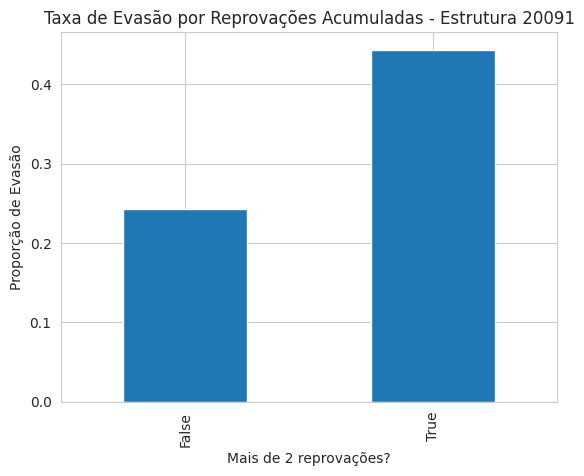


Estrutura: 20191
=== Teste Qui-quadrado ===
Estatística Qui-quadrado: 37.6428
Valor-p: 0.0000
Há associação significativa entre reprovações e evasão.

=== Regressão Logística ===
Optimization terminated successfully.
         Current function value: 0.561158
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 evasao   No. Observations:                  364
Model:                          Logit   Df Residuals:                      362
Method:                           MLE   Df Model:                            1
Date:                Mon, 08 Sep 2025   Pseudo R-squ.:                 0.09411
Time:                        02:48:29   Log-Likelihood:                -204.26
converged:                       True   LL-Null:                       -225.48
Covariance Type:            nonrobust   LLR p-value:                 7.295e-11
                            coef    std err          z      P>|z|      [0.025      0.9

/tmp/ipykernel_582/2605977863.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  alunos_reprovacoes['mais_de_2_reprovacoes'] = alunos_reprovacoes['mais_de_2_reprovacoes'].fillna(False)


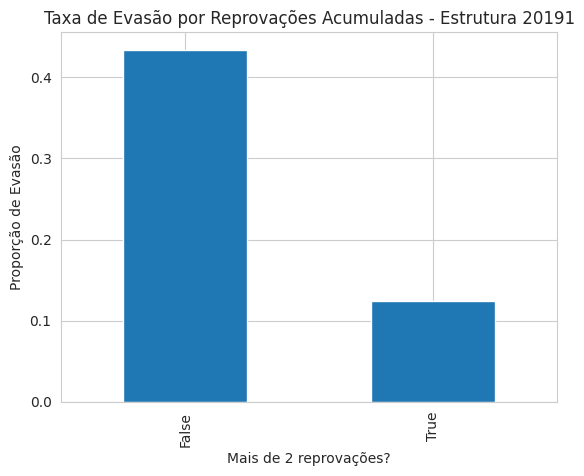

In [ ]:
# --- Loop por estrutura ---
for estrutura, alunos_estrutura in alunos.groupby('estrutura'):
    print(f"\nEstrutura: {estrutura}")
    
    # --- Preparação dos dados ---
    # Cria a variável dependente "evasao" para o grupo atual
    alunos_estrutura['evasao'] = alunos_estrutura['rga_anonimo'].isin(evadidos['rga_anonimo']).astype(int)

    # Filtrar disciplinas obrigatórias do 1º ano (semestres 1 e 2)
    historico_1ano = histEscolar[histEscolar['SE'].isin([1, 2])]
    obrigatorias_1ano = historico_1ano[historico_1ano['Optativa'] == 'Não']

    # Selecionar reprovações
    reprovacoes = obrigatorias_1ano[obrigatorias_1ano['SF'].isin(('RM', 'RMF', 'RF', 'RP'))]

    # Contar reprovações por aluno
    reprovacoes_count = (
        reprovacoes.groupby('rga_anonimo')
        .size()
        .reset_index(name='num_reprovacoes')
    )
    reprovacoes_count['mais_de_2_reprovacoes'] = reprovacoes_count['num_reprovacoes'] > 2

    # Merge com alunos da estrutura
    alunos_reprovacoes = alunos_estrutura.merge(
        reprovacoes_count[['rga_anonimo', 'mais_de_2_reprovacoes']],
        on='rga_anonimo',
        how='left'
    )
    alunos_reprovacoes['mais_de_2_reprovacoes'] = alunos_reprovacoes['mais_de_2_reprovacoes'].fillna(False)

    # --- Teste Qui-quadrado ---
    contingencia = pd.crosstab(
        alunos_reprovacoes['mais_de_2_reprovacoes'],
        alunos_reprovacoes['evasao']
    )

    chi2, p, dof, expected = stats.chi2_contingency(contingencia)

    print("=== Teste Qui-quadrado ===")
    print(f"Estatística Qui-quadrado: {chi2:.4f}")
    print(f"Valor-p: {p:.4f}")
    print("Há associação significativa entre reprovações e evasão." if p < 0.05 
          else "Não há associação significativa entre reprovações e evasão.")

    # --- Regressão Logística ---
    print("\n=== Regressão Logística ===")
    y = alunos_reprovacoes['evasao']
    X = alunos_reprovacoes[['mais_de_2_reprovacoes']].astype(int)
    X = sm.add_constant(X)  # adiciona intercepto

    modelo = sm.Logit(y, X).fit()
    print(modelo.summary())

    # --- Odds Ratios ---
    odds_ratios = np.exp(modelo.params)
    print("\n=== Odds Ratios ===")
    print(odds_ratios)

    taxa_evasao = (
        alunos_reprovacoes.groupby('mais_de_2_reprovacoes')['evasao']
        .mean()
    )
    taxa_evasao.plot(kind='bar', ylabel='Proporção de Evasão', xlabel='Mais de 2 reprovações?')
    plt.title(f'Taxa de Evasão por Reprovações Acumuladas - Estrutura {estrutura}')
    plt.show()



**Conclusões**
* Os resultados obtidos indicam que há evidências estatisticamente significativas de que a evasão esteja associada ao fato de o aluno ter mais de duas reprovações em disciplinas obrigatórias do primeiro ano (Em ambas grades). O 1º gráfico mostra que  taxa de evasão é maior entre quem NÃO teve mais de 2 reprovaçõesde e no 2º gráfico a evasão é maior entre os que tiveram mais de 2 reprovações do que entre os demais.
* Grade 20091:
    * O Teste Qui-quadrado:
        Estatística: 12.3699, valor-p = 0.0004.
        Como p < 0.05, há associação estatisticamente significativa entre número de reprovações e evasão.
    * Regressão Logística
        Coeficiente de mais_de_2_reprovacoes = 0.9968, com p = 0.000.
        O odds ratio = 2.71, sugerindo que quem tem mais de 2 reprovações teria quase 3 vezes mais chance de evadir.
        O pseudo R² = 0.0017 → o modelo explica muito pouco da variabilidade da evasão
* Grade 20191
    * O Teste Qui-quadrado:
        Estatística: 37.6428, valor-p = 0.0000.
        Como p < 0.05, há associação estatisticamente significativa entre número de reprovações e evasão.
    * Regressão Logística
        Coeficiente de mais_de_2_reprovacoes = –1.687, com p = 0.000.
        O odds ratio = 0.18, sugerindo que alunos com mais de 2 reprovações teriam cerca de 82%. O pseudo R² = 0.094 → o modelo explica uma fração modesta da variabilidade da evasão, mas ainda limitada.
* Por fim, há evidências estatisticamente significativas de que ter mais de 2 reprovações no 1º ano aumente a probabilidade de evasão.

2 - **O número de faltas tem correlação negativa significativa com o coeficiente.** → Correlação de Pearson/Spearman

In [ ]:
#→ Correlação de Pearson/Spearman
# Agrupa faltas por aluno no histórico
faltas = (
    histEscolar.groupby('rga_anonimo')['FA']
    .sum()
    .reset_index(name='total_faltas')
)
# Merge com alunos
alunos_faltas = alunos.merge(
    faltas, on='rga_anonimo', how='left'
)
alunos_faltas['total_faltas'] = alunos_faltas['total_faltas'].fillna(0)
# Correlação de Spearman
resultados_corr = []
for estrutura, dados in alunos_faltas.groupby('estrutura'):
    corr, p_value = stats.spearmanr(
        dados['total_faltas'],
        dados['coeficiente'].fillna(0)
    )
    resultados_corr.append({
        "estrutura": estrutura,
        "spearman_corr": corr,
        "p_valor": p_value,
        "significativo": p_value < 0.05
    })
df_corr = pd.DataFrame(resultados_corr)
print(df_corr)


   estrutura  spearman_corr   p_valor  significativo
0      20091      -0.043483  0.414713          False
1      20191       0.014174  0.787540          False


**Conclusões**
* Em ambas as estruturas, não há evidência estatística de correlação entre faltas acumuladas e coeficiente. Os valores da correlação de Spearman está muito próximo de zero, o que indica que não existe uma relação consistente entre o número de faltas e o coeficiente.
* O Valor-p é 0.0.414713 (20091) e 0.787540 (20191), então a hipótese nula não é rejeitada. Logo, não há evidência estatística de que faltas estejam associadas ao coeficiente.

3 - O coeficiente de rendimento médio é diferente entre tipos de ingresso.

In [ ]:
for estrutura, grupo_estrutura in alunos.groupby('estrutura'):
    # Agrupar coeficientes por tipo de ingresso dentro da estrutura
    grupos = [grupo['coeficiente'].dropna().values 
              for _, grupo in grupo_estrutura.groupby('tipo_ingresso')]
    
    # Só faz o teste se houver pelo menos 2 grupos com dados
    if len(grupos) < 2:
        print(f"Estrutura {estrutura}: não há grupos suficientes para o teste.")
        continue
    
    # Teste de Kruskal-Wallis
    stat, p_valor = stats.kruskal(*grupos)
    print(f"Estrutura {estrutura}: H-statistic: {stat:.4f}, Valor-p: {p_valor:.4f}")
    
    if p_valor < 0.05:
        print("  Há diferença significativa no coeficiente entre tipos de ingresso.\n")
    else:
        print("  Não há diferença significativa no coeficiente entre tipos de ingresso.\n")


Estrutura 20091: H-statistic: 7.6767, Valor-p: 0.1750
  Não há diferença significativa no coeficiente entre tipos de ingresso.

Estrutura 20191: H-statistic: 14.7670, Valor-p: 0.0020
  Há diferença significativa no coeficiente entre tipos de ingresso.



**Conclusões**
* Estrutura 20091: H-statistic: 7.6767, Valor-p: 0.1750
  Não há diferença significativa no coeficiente entre tipos de ingresso.

* Estrutura 20191:  H-statistic: 14.7670, Valor-p: 0.0020
  Há diferença significativa no coeficiente entre tipos de ingresso.